In [13]:
# 1. Pipeline up to step2 — needed for stim indices
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from dataset_config import Dutch30Config

config = Dutch30Config()
extractor = Dutch30FeatureExtractor(config=config)
pipeline = Dutch30Pipeline(extractor, config=config, use_wav2vec=False)
pipeline.step1_load_dutch30_data(patient_range=(21, 30))
pipeline.step2_split_by_instances(train_fraction=0.8)
pipeline.step3_load_channel_exclusions('channel_exclusions.json') 
pipeline.apply_channel_exclusions()

# (skip step3-5; no collapsed features)

# 2. Build minimal saved_models from MFA + your manner table
from run_pipeline import load_mfa_alignments
from collections import Counter
import numpy as np

MANNER = {
    # ---- Vowels (manner=0) ----
    # short
    'ɪ': 0, 'ɛ': 0, 'ɑ': 0, 'ɔ': 0, 'ʏ': 0, 'ə': 0, 'a': 0,
    # long / tense
    'i':  0, 'iː': 0, 'eː': 0, 'aː': 0, 'oː': 0,
    'uː': 0, 'yː': 0, 'øː': 0, 'u': 0, 'y': 0, 'e': 0, 'o': 0, 'ɔ̈':  0, 'ɛ̈':  0,
    # diphthongs
    'ɛi': 0, 'ɛj': 0, 'œy': 0, 'ɔu': 0, 'ɑu': 0, 'ɑi': 0, 'au': 0,
    'ui': 0, 'oi': 0, 'œ':  0,

    # ---- Stops / plosives (manner=1) ----
    'p': 1, 'b': 1, 't': 1, 'd': 1, 'k': 1, 'g': 1, 'ɡ': 1,
    'ʔ': 1, 'c':  1,   # palatal stop

    # ---- Fricatives (manner=2) ----
    'f': 2, 'v': 2, 's': 2, 'z': 2, 'x': 2, 'ɣ': 2, 'h': 2,
    'ʃ': 2, 'ʒ': 2, 'ç': 2, 'χ': 2,

    # ---- Nasals (manner=3) ----
    'm': 3, 'n': 3, 'ŋ': 3, 'ɲ': 3,

    # ---- Approximants / liquids (manner=4) ----
    'l': 4, 'r': 4, 'ʁ': 4, 'ɹ': 4, 'j': 4, 'ʋ': 4, 'w': 4, 'ɥ':  4,

    # ---- Affricates (treated as stops for manner) ----
    'ts': 1, 'tʃ': 1, 'dʒ': 1,
}

PLACE = {
    # ---- All vowels = 0 ----
    'ɪ': 0, 'ɛ': 0, 'ɑ': 0, 'ɔ': 0, 'ʏ': 0, 'ə': 0, 'a': 0,
    'i':  0, 'iː': 0, 'eː': 0, 'aː': 0, 'oː': 0,
    'uː': 0, 'yː': 0, 'øː': 0, 'u': 0, 'y': 0, 'e': 0, 'o': 0,
    'ɛi': 0, 'ɛj': 0, 'œy': 0, 'ɔu': 0, 'ɑu': 0, 'ɑi': 0, 'au': 0,
    'ui': 0, 'oi': 0, 'œ':  0, 'ɔ̈':  0, 'ɛ̈':  0,

    # ---- Bilabial (1): p b m ----
    'p': 1, 'b': 1, 'm': 1,

    # ---- Labiodental (2): f v ʋ ----
    'f': 2, 'v': 2, 'ʋ': 2, 'w': 2,

    # ---- Alveolar (3): t d s z n l r ts ----
    't': 3, 'd': 3, 's': 3, 'z': 3, 'n': 3, 'l': 3,
    'r': 3, 'ɹ': 3, 'ts': 3,

    # ---- Postalveolar (4): ʃ ʒ tʃ dʒ ----
    'ʃ': 4, 'ʒ': 4, 'tʃ': 4, 'dʒ': 4,

    # ---- Velar (5): k g x ɣ ŋ ----
    'k': 5, 'g': 5, 'ɡ': 5, 'x': 5, 'ɣ': 5, 'ŋ': 5,
    'χ': 5, 'ʁ': 5,

    # ---- Glottal (6): h ʔ ----
    'h': 6, 'ʔ': 6,

    # ---- Palatal (7): j ɲ ç ----
    'j': 7, 'ɲ': 7, 'ç': 7, 'c':  7, 'ɥ':  7,
}


def build_saved_state(pid, pipeline):
    wd = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)
    train_sent_ids = set()
    if 'train' in pipeline.split_result:
        for inst in pipeline.split_result['train'].get(pid, []):
            if isinstance(inst, dict) and 'sentence_idx' in inst:
                train_sent_ids.add(inst['sentence_idx'])
    if not train_sent_ids:
        all_real = [i for i, s in enumerate(wd['sentence_list'])
                    if isinstance(s, dict) and s.get('text')]
        train_sent_ids = set(i for i in all_real if i not in all_real[::6])

    # phoneme inventory from train sentences only (leak-safe)
    phons = []
    for sidx in train_sent_ids:
        if sidx in mfa:
            phons.extend(p['phone'] for p in mfa[sidx])
    inv = sorted(set(phons))
    cls_to_i = {ph: i for i, ph in enumerate(inv)}

    # bigram log-probs from train
    n = len(inv)
    bg = np.ones((n, n), dtype=np.float32)   # Laplace smoothing
    for sidx in train_sent_ids:
        if sidx not in mfa: continue
        seq = [cls_to_i[p['phone']] for p in mfa[sidx]
               if p['phone'] in cls_to_i]
        for a, b in zip(seq[:-1], seq[1:]):
            bg[a, b] += 1
    bg_lp = np.log(bg / bg.sum(axis=1, keepdims=True))

    # phone_to_manner array
    pm_arr = np.array([MANNER.get(ph, 0) for ph in inv], dtype=int)

    return {'cls_to_i': cls_to_i, 'bg_lp': bg_lp,
            'phone_to_manner': pm_arr}

# ---- Coverage check against the actual phonemes in your MFA output ----
def check_coverage(saved_models, manner=MANNER, place=PLACE):
    missing_manner = set()
    missing_place = set()
    for pid, st in saved_models.items():
        for ph in st['cls_to_i'].keys():
            if ph not in manner: missing_manner.add(ph)
            if ph not in place: missing_place.add(ph)
    if missing_manner:
        print(f"MISSING from MANNER: {sorted(missing_manner)}")
    if missing_place:
        print(f"MISSING from PLACE: {sorted(missing_place)}")
    if not missing_manner and not missing_place:
        print("All phonemes covered.")

saved_models = {pid: build_saved_state(pid, pipeline)
                for pid in ['P22', 'P23', 'P26', 'P29']}

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, groups=False

In [14]:
check_coverage(saved_models) 

All phonemes covered.


In [76]:
# ============================================================
# Signal processing — Butterworth-LP envelope (replaces boxcar mean)
# ============================================================
import numpy as np
from scipy.signal import butter, sosfiltfilt, iirnotch, tf2sos, hilbert

EEG_SR     = 1024
HG_LOW     = 70
HG_HIGH    = 170
NOTCH_HZ   = [50, 150]
LP_CUT_HZ  = 12.0          
N_BUTTER   = 4
SHIFT_MS   = 5
SHIFT_SAMP = int(EEG_SR * SHIFT_MS / 1000)
FRAME_HZ   = int(1000 / SHIFT_MS)   # 200 Hz

def _design_filters():
    sos_bp = butter(N_BUTTER, [HG_LOW, HG_HIGH], btype='bandpass',
                    fs=EEG_SR, output='sos')
    sos_lp = butter(N_BUTTER, LP_CUT_HZ, btype='lowpass',
                    fs=EEG_SR, output='sos')
    sos_notches = []
    for f0 in NOTCH_HZ:
        b, a = iirnotch(f0, 30, EEG_SR)
        sos_notches.append(tf2sos(b, a))
    return sos_bp, sos_lp, sos_notches

_SOS_BP, _SOS_LP, _SOS_NOTCH = _design_filters()

def extract_hg_frames(eeg_slice):
    """Raw EEG → 200 Hz high-gamma envelope.
       Butterworth 5 Hz lowpass (no boxcar) + decimation."""
    x = eeg_slice.astype(np.float64)
    for sos in _SOS_NOTCH:
        x = sosfiltfilt(sos, x, axis=0)
    x = sosfiltfilt(_SOS_BP, x, axis=0)
    env = np.abs(hilbert(x, axis=0))
    env = sosfiltfilt(_SOS_LP, env, axis=0)         # ← uses LP_CUT_HZ above
    env = np.maximum(env, 0)                         # clamp filter ringing
    out = env[::SHIFT_SAMP].astype(np.float32)
    return np.log1p(out)

def stack_context(X, K=5):
    T, C = X.shape
    pad = np.zeros((K, C), dtype=X.dtype)
    Xp = np.vstack([pad, X, pad])
    cols = [Xp[k:k + T] for k in range(2 * K + 1)]
    return np.concatenate(cols, axis=1)

print(f"Signal processing: LP cutoff = {LP_CUT_HZ} Hz, Butterworth order {N_BUTTER}")

Signal processing: LP cutoff = 12.0 Hz, Butterworth order 4


In [33]:
# # Load speech vs non speech detector
# import torch.nn as nn

# class SpeechDetector(nn.Module):
#     """Per-patient speech-vs-non-speech model."""
#     def __init__(self, n_in, lstm_hidden=128, lstm_layers=2, dropout=0.2):
#         super().__init__()
#         self.proj = nn.Sequential(
#             nn.Linear(n_in, lstm_hidden * 2), nn.GELU(), nn.Dropout(dropout))
#         self.lstm = nn.LSTM(lstm_hidden * 2, lstm_hidden,
#                             num_layers=lstm_layers,
#                             dropout=dropout if lstm_layers > 1 else 0.0,
#                             bidirectional=True, batch_first=False)
#         self.head = nn.Linear(lstm_hidden * 2, 2)

#     def forward(self, x):
#         h = self.proj(x).unsqueeze(1)
#         h, _ = self.lstm(h)
#         return self.head(h.squeeze(1))


# class CrossPatientSpeechDetector(nn.Module):
#     """Per-patient input projection feeds into a shared BiLSTM + head."""
#     def __init__(self, n_in_per_pid, embed_dim=128,
#                  lstm_hidden=128, lstm_layers=2, dropout=0.2):
#         super().__init__()
#         self.projs = nn.ModuleDict({
#             pid: nn.Sequential(nn.Linear(n_in, embed_dim), nn.GELU(),
#                                nn.Dropout(dropout))
#             for pid, n_in in n_in_per_pid.items()
#         })
#         self.lstm = nn.LSTM(embed_dim, lstm_hidden, num_layers=lstm_layers,
#                             dropout=dropout if lstm_layers > 1 else 0.0,
#                             bidirectional=True, batch_first=False)
#         self.head = nn.Linear(lstm_hidden * 2, 2)

#     def forward(self, x, pid):
#         h = self.projs[pid](x).unsqueeze(1)
#         h, _ = self.lstm(h)
#         return self.head(h.squeeze(1))
        
# ckpt = torch.load('bio_models/speech_detector_cross_patient.pt',
#                   map_location=DEVICE, weights_only=False)
# sd_model = CrossPatientSpeechDetector(
#     n_in_per_pid=ckpt['n_in_per_pid'],
#     **ckpt['arch']).to(DEVICE)
# sd_model.load_state_dict(ckpt['state_dict'])
# sd_model.eval()
# # remember per-patient mu/sd for standardizing the input
# mu_sd_speech = ckpt['mu_sd']

In [70]:
# ============================================================
# Path B v2 — training (BIO-CRF, mixup augmentation, composite selection)
# ============================================================
import time, torch.optim as optim

EPOCHS         = 40
LR             = 3e-4
WEIGHT_DECAY   = 1e-3
LAM_MANNER     = 0.3
LAM_PLACE      = 0.1
LAM_BIO_CE     = 0.5
GRAD_CLIP      = 5.0
MIN_SENT_FRAMES = 30
EARLY_STOP_PATIENCE = 1   # in evaluation cycles (every 5 epochs)

P_AUG          = 0.5
AUG_FRAC       = 0.2
MIX_RATIO      = 0.8
MIN_PHON_LEN_FOR_AUG = 6


def split_into_sentences_v2(split_dict, tag_to_idx):
    sents = []
    sidx = split_dict['sent_idx']
    boundaries = np.where(np.diff(sidx, prepend=sidx[0]-1) != 0)[0].tolist() + [len(sidx)]
    n_oov = 0
    for k in range(len(boundaries) - 1):
        s, e = boundaries[k], boundaries[k + 1]
        if e - s < MIN_SENT_FRAMES: continue
        bio_str_full = split_dict['bio'][s:e]
        keep_local = np.array([t in tag_to_idx for t in bio_str_full])
        n_oov += int((~keep_local).sum())
        if keep_local.sum() < MIN_SENT_FRAMES: continue
        bio_str = bio_str_full[keep_local]
        tags = np.array([tag_to_idx[t] for t in bio_str], dtype=np.int64)
        mid_mask = np.zeros(len(tags), dtype=bool)
        i = 0
        while i < len(bio_str):
            if bio_str[i].startswith('B-'):
                ph = bio_str[i][2:]; j = i + 1
                while j < len(bio_str) and bio_str[j] == f'I-{ph}': j += 1
                if (j - i) >= MIN_PHON_LEN_FOR_AUG:
                    mid_mask[i + 2: j - 2] = True
                i = j
            else: i += 1
        sents.append({
            'X':      torch.from_numpy(split_dict['X'][s:e][keep_local]).float(),
            'tags':   torch.from_numpy(tags),
            'manner': torch.from_numpy(split_dict['manner'][s:e][keep_local]),
            'place':  torch.from_numpy(split_dict['place'][s:e][keep_local]),
            'mid':    torch.from_numpy(mid_mask),
            'sent_idx': int(sidx[s]),
        })
    if n_oov: print(f"  dropped {n_oov} OOV-tag frames")
    return sents

def fit_mu_sd(sents):
    Xall = torch.cat([s['X'].cpu() for s in sents], dim=0).numpy()
    return Xall.mean(0), Xall.std(0)

def standardize(sents, mu, sd):
    sd_safe = np.where(sd < 1e-6, 1.0, sd)
    for s in sents:
        device = s['X'].device
        mu_t = torch.from_numpy(mu).float().to(device)
        sd_t = torch.from_numpy(sd_safe).float().to(device)
        s['X'] = (s['X'] - mu_t) / sd_t

def to_device(sents, device):
    for s in sents:
        for k in ('X', 'tags', 'manner', 'place', 'mid'):
            s[k] = s[k].to(device)

def make_ce_weights(sents_tr, n_tags, device):
    cnt = torch.zeros(n_tags)
    for s in sents_tr:
        for t in s['tags'].cpu().tolist(): cnt[t] += 1
    cnt = cnt.clamp(min=1.0)
    return (cnt.sum() / (n_tags * cnt)).clamp(min=0.2, max=5.0).to(device)

def augment_sentence(s_anchor, partner_pool, p_aug, aug_frac, mix_ratio, rng):
    if rng.random() > p_aug or s_anchor['mid'].sum() == 0:
        return s_anchor['X']
    mid_idx = s_anchor['mid'].nonzero(as_tuple=False).flatten()
    n_perturb = max(1, int(len(mid_idx) * aug_frac))
    perm = mid_idx[torch.randperm(len(mid_idx), device=mid_idx.device)[:n_perturb]]
    partner = partner_pool[rng.integers(0, len(partner_pool))]
    if partner['X'].size(0) == 0: return s_anchor['X']
    p_idx = torch.randint(0, partner['X'].size(0), (n_perturb,),
                          device=partner['X'].device)
    X = s_anchor['X'].clone()
    X[perm] = mix_ratio * X[perm] + (1.0 - mix_ratio) * partner['X'][p_idx]
    return X

def evaluate_for_selection(model, sents_te, idx_to_tag):
    model.eval()
    correct = total = 0; pred_symbols = set(); n_pred = 0
    with torch.no_grad():
        for s in sents_te:
            path = model.decode(s['X'])
            for p, t in zip(path, s['tags'].tolist()):
                correct += (p == t); total += 1
            for p in path:
                tag = idx_to_tag[int(p)]
                if tag.startswith('B-'):
                    pred_symbols.add(tag[2:]); n_pred += 1
    tag_acc = correct / max(total, 1)
    diversity = min(1.0, len(pred_symbols) / 3.0)
    coverage = min(1.0, n_pred / max(1, total / 34))
    return tag_acc * diversity * coverage, tag_acc, len(pred_symbols), n_pred


def train_v2(pid, frame_datasets_v2, saved_models, epochs=EPOCHS, **arch):
    fd = frame_datasets_v2[pid]
    if fd['train'] is None or fd['test'] is None: return None
    model, tag_to_idx, idx_to_tag = make_model_v2(
        pid, frame_datasets_v2, saved_models, **arch)
    model = model.to(DEVICE)

    sents_tr = split_into_sentences_v2(fd['train'], tag_to_idx)
    sents_te = split_into_sentences_v2(fd['test'],  tag_to_idx)
    if not sents_tr: return None
    mu, sd = fit_mu_sd(sents_tr)
    standardize(sents_tr, mu, sd); standardize(sents_te, mu, sd)
    to_device(sents_tr, DEVICE); to_device(sents_te, DEVICE)
    ce_weights = make_ce_weights(sents_tr, model.n_tags, DEVICE)

    opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    rng = np.random.default_rng(0)
    best_score, best_state, no_improve = 0.0, None, 0

    for ep in range(epochs):
        model.train()
        perm = rng.permutation(len(sents_tr))
        losses = {'total': 0, 'crf': 0, 'bio_ce': 0, 'mn': 0, 'pl': 0}
        for idx in perm:
            s = sents_tr[idx]
            X_aug = augment_sentence(s, sents_tr, P_AUG, AUG_FRAC, MIX_RATIO, rng)
            opt.zero_grad()
            loss, parts = model.loss(
                X_aug, s['tags'], s['manner'], s['place'],
                lam_manner=LAM_MANNER, lam_place=LAM_PLACE,
                lam_bio_ce=LAM_BIO_CE, ce_weights=ce_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            losses['total'] += float(loss.item())
            for k in ('crf', 'bio_ce', 'mn', 'pl'): losses[k] += parts[k]
        sched.step()

        if (ep + 1) % 5 == 0 or ep == 0:
            score, tag_acc, n_uniq, n_pred = evaluate_for_selection(
                model, sents_te, idx_to_tag)
            improved = score > best_score
            if improved and ep >= 5:
                best_score = score
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model.state_dict().items()}
                no_improve = 0
            elif ep >= 5:                   # ← only count during post-warmup
                no_improve += 1
            # else: warmup phase, don't touch no_improve

            n = len(sents_tr)
            print(f"  [{pid}] ep{ep+1:3d}  "
                  f"loss={losses['total']/n:.2f} crf={losses['crf']/n:.2f} "
                  f"bio_ce={losses['bio_ce']/n:.2f}  "
                  f"score={score:.3f} tag={tag_acc:.3f} "
                  f"n_uniq={n_uniq} n_pred={n_pred} "
                  f"(best={best_score:.3f})")
            if no_improve >= EARLY_STOP_PATIENCE:
                print(f"  [{pid}] early stop at ep {ep+1}"); break

    if best_state is None:
        print(f"  [{pid}] WARNING: never improved, saving final-epoch")
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)

    return {'model': model, 'mu': mu, 'sd': sd,
            'tag_to_idx': tag_to_idx, 'idx_to_tag': idx_to_tag,
            'sents_tr': sents_tr, 'sents_te': sents_te,
            'best_acc': best_score}


bio_results_v2 = {}
for pid in TARGET_PIDS:
    if pid not in frame_datasets_v2 or frame_datasets_v2[pid]['train'] is None:
        continue
    print(f"\n=== Training {pid} ===")
    t0 = time.time()
    bio_results_v2[pid] = train_v2(
        pid, frame_datasets_v2, saved_models, epochs=EPOCHS,
        lstm_hidden=128, lstm_layers=2, lstm_dropout=0.3, head_dropout=0.3)
    if bio_results_v2[pid]:
        print(f"  [{pid}] done in {time.time() - t0:.1f}s")


=== Training P22 ===
  [P22] ep  1  loss=3.95 crf=1.17 bio_ce=4.28  score=0.000 tag=0.058 n_uniq=0 n_pred=0 (best=0.000)
  [P22] ep  5  loss=2.96 crf=0.41 bio_ce=3.98  score=0.003 tag=0.078 n_uniq=6 n_pred=12 (best=0.000)
  [P22] ep 10  loss=2.47 crf=0.32 bio_ce=3.38  score=0.063 tag=0.108 n_uniq=25 n_pred=171 (best=0.063)
  [P22] ep 15  loss=1.78 crf=0.24 bio_ce=2.46  score=0.082 tag=0.091 n_uniq=25 n_pred=262 (best=0.082)
  [P22] ep 20  loss=1.25 crf=0.18 bio_ce=1.72  score=0.089 tag=0.089 n_uniq=27 n_pred=299 (best=0.089)
  [P22] ep 25  loss=0.95 crf=0.15 bio_ce=1.29  score=0.103 tag=0.103 n_uniq=27 n_pred=317 (best=0.103)
  [P22] ep 30  loss=0.80 crf=0.14 bio_ce=1.08  score=0.113 tag=0.113 n_uniq=26 n_pred=316 (best=0.113)
  [P22] ep 35  loss=0.74 crf=0.13 bio_ce=0.99  score=0.102 tag=0.102 n_uniq=27 n_pred=318 (best=0.113)
  [P22] early stop at ep 35
  [P22] done in 723.8s

=== Training P23 ===
  [P23] ep  1  loss=3.92 crf=1.16 bio_ce=4.28  score=0.000 tag=0.026 n_uniq=0 n_pred=0

In [71]:
def collapse_bio_to_segments(bio_tag_strs):
    phons, starts, ends = [], [], []
    i = 0
    while i < len(bio_tag_strs):
        t = bio_tag_strs[i]
        if t.startswith('B-') or t.startswith('I-'):
            sym = t[2:]; j = i + 1
            while j < len(bio_tag_strs) and bio_tag_strs[j] == f'I-{sym}': j += 1
            phons.append(sym); starts.append(i); ends.append(j); i = j
        else: i += 1
    return phons, starts, ends

# Build pipeline.patient_results then score
if not hasattr(pipeline, 'patient_results') or pipeline.patient_results is None:
    pipeline.patient_results = {}

def bio_results_to_pr(pid, res_dict):
    res = res_dict[pid]; model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    preds, golds, p_sids, g_sids = [], [], [], []
    with torch.no_grad():
        for s in res['sents_te']:
            path = model.decode(s['X'])
            pp, _, _ = collapse_bio_to_segments([idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments([idx_to_tag[int(t)] for t in s['tags'].tolist()])
            for ph in pp: preds.append(ph); p_sids.append(s['sent_idx'])
            for ph in gp: golds.append(ph); g_sids.append(s['sent_idx'])
    return {'true_labels': np.array(golds), 'predictions': np.array(preds),
            'true_sentence_ids': np.array(g_sids),
            'pred_sentence_ids': np.array(p_sids)}

for pid in bio_results_v2:
    pipeline.patient_results[pid] = bio_results_to_pr(pid, bio_results_v2)

# Surprise z
for pid in TARGET_PIDS:
    if pid not in pipeline.patient_results: continue
    pr = pipeline.patient_results[pid]
    pred_sents, gold_sents = [], []
    for sid in np.unique(pr['true_sentence_ids']):
        pmask = pr['pred_sentence_ids'] == sid
        gmask = pr['true_sentence_ids'] == sid
        pred_sents.append(list(pr['predictions'][pmask]))
        gold_sents.append(list(pr['true_labels'][gmask]))
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} v2-lp5", gold_lp)


=== P22 ===
[P22 v2-lp5] sents=16 max_run=4 n_matches(>=3)=1 obs=10.25 null mu=3.01 sd=5.01  z=+1.44

=== P23 ===
[P23 v2-lp5] sents=15 max_run=3 n_matches(>=3)=1 obs=8.68 null mu=2.85 sd=4.95  z=+1.18

=== P26 ===
[P26 v2-lp5] sents=12 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=2.56 sd=4.64  z=-0.55

=== P29 ===
[P29 v2-lp5] sents=17 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=0.92 sd=2.78  z=-0.33


In [73]:
# LP sweep 
#import time
# import torch

# LP_VALUES   = [5.0, 7.0, 10.0, 12.0]
# K_VALUES    = [5, 8, 12]
# SWEEP_PIDS  = ['P22', 'P29']     # one strong, one weak

# def make_extract_hg(lp_cut_hz, n_butter=4):
#     sos_lp = butter(n_butter, lp_cut_hz, btype='lowpass', fs=EEG_SR, output='sos')
#     def fn(eeg_slice):
#         x = eeg_slice.astype(np.float64)
#         for sos in _SOS_NOTCH:
#             x = sosfiltfilt(sos, x, axis=0)
#         x = sosfiltfilt(_SOS_BP, x, axis=0)
#         env = np.abs(hilbert(x, axis=0))
#         env = sosfiltfilt(sos_lp, env, axis=0)
#         env = np.maximum(env, 0)
#         out = env[::SHIFT_SAMP].astype(np.float32)
#         return np.log1p(out)
#     return fn


# def build_dataset_param(pid, pipeline, saved_models, extract_fn, K, channel_mask=None):
#     """Same as build_frame_dataset_v2 but uses passed extract_fn and K."""
#     raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
#     if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
#         raw_eeg = raw_eeg.T
#     if channel_mask is not None:
#         raw_eeg = raw_eeg[:, channel_mask]

#     wd  = pipeline.split_result['word_segments_dict'][pid]
#     mfa = load_mfa_alignments(pid)
#     all_real = [i for i, s in enumerate(wd['sentence_list'])
#                 if isinstance(s, dict) and s.get('text')]
#     test_sent_ids = set(all_real[::6])
#     manner_map = get_manner_table(saved_models, pid)

#     out = {'train': defaultdict(list), 'test': defaultdict(list)}
#     for sent_idx in all_real:
#         if sent_idx not in mfa or not mfa[sent_idx]: continue
#         s = wd['sentence_list'][sent_idx]
#         s0, s1 = s['stim_start_idx'], s['stim_end_idx']
#         if s1 > raw_eeg.shape[0]: continue
#         X = extract_fn(raw_eeg[s0:s1])
#         if X.shape[0] < 11: continue
#         bio, phon, keep = build_speech_only_labels(mfa[sent_idx], X.shape[0])
#         if keep.sum() < 11: continue
#         Xs = stack_context(X, K=K)
#         bio_arr = np.array([b for b, k in zip(bio, keep) if k])
#         phon_arr = np.array([p for p, k in zip(phon, keep) if k])
#         manner_arr = np.array([manner_map.get(p, -1) for p in phon_arr], dtype=np.int64)
#         place_arr  = np.array([PLACE_TABLE.get(p, -1) for p in phon_arr], dtype=np.int64)
#         sidx_arr = np.full(int(keep.sum()), sent_idx, dtype=int)
#         split = 'test' if sent_idx in test_sent_ids else 'train'
#         out[split]['X'].append(Xs[keep])
#         out[split]['bio'].append(bio_arr)
#         out[split]['phon'].append(phon_arr)
#         out[split]['manner'].append(manner_arr)
#         out[split]['place'].append(place_arr)
#         out[split]['sent_idx'].append(sidx_arr)

#     result = {}
#     for split in ('train', 'test'):
#         if not out[split]['X']:
#             result[split] = None; continue
#         result[split] = {k: (np.concatenate(v, axis=0) if isinstance(v[0], np.ndarray)
#                              else v) for k, v in out[split].items()}
#     return result


# def score_one_run(pid, results_dict):
#     """Compute surprise z + max_run for a trained model."""
#     res = results_dict[pid]; model = res['model']; model.eval()
#     idx_to_tag = res['idx_to_tag']
#     pred_sents, gold_sents = [], []
#     with torch.no_grad():
#         for s in res['sents_te']:
#             path = model.decode(s['X'])
#             pp, _, _ = collapse_bio_to_segments([idx_to_tag[int(t)] for t in path])
#             gp, _, _ = collapse_bio_to_segments(
#                 [idx_to_tag[int(t)] for t in s['tags'].tolist()])
#             pred_sents.append(pp); gold_sents.append(gp)
#     all_gold = [ph for s in gold_sents for ph in s]
#     if not all_gold:
#         return {'z': 0.0, 'max_run': 0, 'n_matches': 0}
#     cnt = Counter(all_gold); N = sum(cnt.values())
#     gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
#     runs = [longest_run_with_shift(p, g)[0]
#             for p, g in zip(pred_sents, gold_sents)]
#     max_run = max(runs) if runs else 0
#     matches = collect_matches(pred_sents, gold_sents)
#     obs = surprise_score(matches, gold_lp)
#     nulls = perm_null(pred_sents, gold_sents, gold_lp, n_perm=1000)
#     mu, sd = nulls.mean(), nulls.std() + 1e-9
#     z = (obs - mu) / sd
#     return {'z': float(z), 'max_run': max_run, 'n_matches': len(matches)}


# # Run sweep
# sweep_results = {}
# for lp in LP_VALUES:
#     extract_fn = make_extract_hg(lp)
#     for K in K_VALUES:
#         for pid in SWEEP_PIDS:
#             key = (lp, K, pid)
#             print(f"\n=== LP={lp}  K={K}  {pid} ===")
#             t0 = time.time()
#             ds = {pid: build_dataset_param(pid, pipeline, saved_models, extract_fn, K)}
#             res = train_v2(
#                 pid, ds, saved_models, epochs=30,         # shorter for sweep speed
#                 lstm_hidden=128, lstm_layers=2,
#                 lstm_dropout=0.3, head_dropout=0.3)
#             if res is not None:
#                 sweep_results[key] = score_one_run(pid, {pid: res})
#                 sweep_results[key]['runtime'] = time.time() - t0
#                 print(f"   z={sweep_results[key]['z']:+.2f}  "
#                       f"max_run={sweep_results[key]['max_run']}  "
#                       f"n_matches={sweep_results[key]['n_matches']}  "
#                       f"({sweep_results[key]['runtime']:.0f}s)")

# # Print summary table
# print("\n========== SWEEP SUMMARY ==========")
# print(f"{'LP':>4}  {'K':>4}  {'patient':>8}  {'z':>7}  {'max_run':>8}  {'matches':>8}")
# for (lp, K, pid), v in sorted(sweep_results.items()):
#     print(f"{lp:>4.1f}  {K:>4d}  {pid:>8}  {v['z']:+7.2f}  {v['max_run']:>8d}  {v['n_matches']:>8d}")


=== LP=5.0  K=5  P22 ===
  [P22] ep  1  loss=4.00 crf=1.22 bio_ce=4.28  score=0.000 tag=0.084 n_uniq=0 n_pred=0 (best=0.000)
  [P22] ep  5  loss=2.97 crf=0.41 bio_ce=4.00  score=0.006 tag=0.092 n_uniq=7 n_pred=20 (best=0.000)
  [P22] ep 10  loss=2.49 crf=0.33 bio_ce=3.40  score=0.035 tag=0.073 n_uniq=22 n_pred=138 (best=0.035)
  [P22] ep 15  loss=1.81 crf=0.25 bio_ce=2.50  score=0.086 tag=0.108 n_uniq=30 n_pred=234 (best=0.086)
  [P22] ep 20  loss=1.36 crf=0.20 bio_ce=1.87  score=0.089 tag=0.090 n_uniq=28 n_pred=289 (best=0.089)
  [P22] ep 25  loss=1.18 crf=0.18 bio_ce=1.61  score=0.098 tag=0.099 n_uniq=28 n_pred=289 (best=0.098)
  [P22] ep 30  loss=1.14 crf=0.17 bio_ce=1.55  score=0.100 tag=0.104 n_uniq=27 n_pred=281 (best=0.100)
   z=+3.31  max_run=3  n_matches=2  (596s)

=== LP=5.0  K=5  P29 ===
  dropped 33 OOV-tag frames
  [P29] ep  1  loss=4.03 crf=1.25 bio_ce=4.27  score=0.000 tag=0.101 n_uniq=0 n_pred=0 (best=0.000)
  [P29] ep  5  loss=3.06 crf=0.42 bio_ce=4.09  score=0.002 ta

In [75]:
# LP sweep
# # Extended sweep: higher LP cutoffs, all four target patients
# # ============================================================
# import time
# import torch
# import numpy as np
# from collections import Counter, defaultdict

# # Sweep grid — adjust if you want different bounds
# LP_VALUES   = [12.0, 15.0, 18.0, 22.0, 28.0]
# K_VALUES    = [5, 10]
# SWEEP_PIDS  = ['P22', 'P23', 'P26', 'P29']

# # (make_extract_hg, build_dataset_param, score_one_run, train_v2 are
# #  already defined from previous cells. If you cleared the kernel, paste
# #  them again from earlier.)

# sweep_results_ext = {}
# total_combos = len(LP_VALUES) * len(K_VALUES) * len(SWEEP_PIDS)
# done = 0
# t_sweep_start = time.time()

# for lp in LP_VALUES:
#     extract_fn = make_extract_hg(lp)
#     for K in K_VALUES:
#         for pid in SWEEP_PIDS:
#             key = (lp, K, pid)
#             done += 1
#             elapsed = time.time() - t_sweep_start
#             eta_min = (elapsed / max(done - 1, 1)) * (total_combos - done) / 60 if done > 1 else 0
#             print(f"\n=== [{done}/{total_combos}] LP={lp}  K={K}  {pid}   "
#                   f"(elapsed {elapsed/60:.1f}min, ~{eta_min:.0f}min remaining) ===")
#             t0 = time.time()
#             try:
#                 ds = {pid: build_dataset_param(pid, pipeline, saved_models,
#                                                 extract_fn, K)}
#                 if ds[pid]['train'] is None or ds[pid]['test'] is None:
#                     print(f"   [{pid}] no train/test data, skipping")
#                     continue
#                 res = train_v2(
#                     pid, ds, saved_models, epochs=30,
#                     lstm_hidden=128, lstm_layers=2,
#                     lstm_dropout=0.3, head_dropout=0.3)
#                 if res is None:
#                     print("   train_v2 returned None, skipping"); continue
#                 sc = score_one_run(pid, {pid: res})
#                 sc['runtime'] = time.time() - t0
#                 sweep_results_ext[key] = sc
#                 print(f"   z={sc['z']:+.2f}  max_run={sc['max_run']}  "
#                       f"n_matches={sc['n_matches']}  ({sc['runtime']:.0f}s)")
#             except Exception as e:
#                 print(f"   FAILED: {type(e).__name__}: {e}")

# # ============================================================
# # Summary tables
# # ============================================================
# print(f"\n========== SWEEP COMPLETE ({(time.time()-t_sweep_start)/60:.1f} min) ==========\n")

# print("Per-cell results:")
# print(f"{'LP':>5}  {'K':>4}  {'patient':>8}  {'z':>7}  {'max_run':>8}  {'matches':>8}")
# for (lp, K, pid), v in sorted(sweep_results_ext.items()):
#     print(f"{lp:>5.1f}  {K:>4d}  {pid:>8}  {v['z']:+7.2f}  {v['max_run']:>8d}  {v['n_matches']:>8d}")

# # Per-patient best
# print("\nBest config per patient:")
# for pid in SWEEP_PIDS:
#     cells = {k: v for k, v in sweep_results_ext.items() if k[2] == pid}
#     if not cells: continue
#     best_key, best_val = max(cells.items(), key=lambda kv: kv[1]['z'])
#     lp, K, _ = best_key
#     print(f"  {pid}:  LP={lp}  K={K}  →  z={best_val['z']:+.2f}  "
#           f"max_run={best_val['max_run']}  matches={best_val['n_matches']}")

# # LP-averaged across K and patients (rough trend)
# print("\nz averaged across K and patients per LP:")
# for lp in LP_VALUES:
#     zs = [v['z'] for k, v in sweep_results_ext.items() if k[0] == lp]
#     if zs:
#         print(f"  LP={lp:.1f}:  mean z = {np.mean(zs):+.2f}  "
#               f"(n={len(zs)}, max={max(zs):+.2f})")

# # K-averaged across LP and patients
# print("\nz averaged across LP and patients per K:")
# for K in K_VALUES:
#     zs = [v['z'] for k, v in sweep_results_ext.items() if k[1] == K]
#     if zs:
#         print(f"  K={K}:    mean z = {np.mean(zs):+.2f}  "
#               f"(n={len(zs)}, max={max(zs):+.2f})")


=== [1/40] LP=12.0  K=5  P22   (elapsed 0.0min, ~0min remaining) ===
  [P22] ep  1  loss=3.98 crf=1.20 bio_ce=4.28  score=0.000 tag=0.058 n_uniq=0 n_pred=0 (best=0.000)
  [P22] ep  5  loss=2.95 crf=0.41 bio_ce=3.98  score=0.003 tag=0.086 n_uniq=4 n_pred=9 (best=0.000)
  [P22] ep 10  loss=2.42 crf=0.31 bio_ce=3.36  score=0.048 tag=0.092 n_uniq=22 n_pred=153 (best=0.048)
  [P22] ep 15  loss=1.73 crf=0.22 bio_ce=2.47  score=0.079 tag=0.098 n_uniq=25 n_pred=236 (best=0.079)
  [P22] ep 20  loss=1.30 crf=0.18 bio_ce=1.85  score=0.096 tag=0.096 n_uniq=27 n_pred=293 (best=0.096)
  [P22] ep 25  loss=1.11 crf=0.16 bio_ce=1.59  score=0.106 tag=0.106 n_uniq=26 n_pred=310 (best=0.106)
  [P22] ep 30  loss=1.07 crf=0.15 bio_ce=1.53  score=0.106 tag=0.106 n_uniq=25 n_pred=309 (best=0.106)
   z=+2.37  max_run=3  n_matches=2  (572s)

=== [2/40] LP=12.0  K=5  P23   (elapsed 9.5min, ~362min remaining) ===
  [P23] ep  1  loss=3.99 crf=1.23 bio_ce=4.28  score=0.001 tag=0.063 n_uniq=2 n_pred=4 (best=0.000)


KeyboardInterrupt: 

In [42]:
# Path B v3 — joint dataset: keep all frames, two label streams
# ============================================================
import os, numpy as np, torch
from collections import defaultdict, Counter
from config import DUTCH_30_PATH
from run_pipeline import load_mfa_alignments

PRE_ONSET_MS     = 200
PRE_ONSET_FRAMES = int(PRE_ONSET_MS / SHIFT_MS)

def build_speech_label_full(mfa_phones, n_frames):
    """Per-frame binary speech label (with pre-onset extension)."""
    label = np.zeros(n_frames, dtype=np.int64)
    for ph in mfa_phones:
        k_start = int(np.ceil(ph['start_s']  * FRAME_HZ))
        k_end   = int(np.floor(ph['end_s']   * FRAME_HZ))
        k_pre   = max(0, k_start - PRE_ONSET_FRAMES)
        k_start = max(0, k_start); k_end = min(n_frames - 1, k_end)
        if k_end < k_pre: continue
        label[k_pre:k_end + 1] = 1
    return label

def build_joint_dataset_v3(pid, pipeline, channel_mask=None):
    raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    if channel_mask is not None:
        raw_eeg = raw_eeg[:, channel_mask]

    wd  = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)

    all_real = [i for i, s in enumerate(wd['sentence_list'])
                if isinstance(s, dict) and s.get('text')]
    test_sent_ids = set(all_real[::6])

    manner_map = get_manner_table(saved_models, pid)

    sents = {'train': [], 'test': []}
    n_used = n_skip = 0
    for sent_idx in all_real:
        if sent_idx not in mfa or not mfa[sent_idx]:
            n_skip += 1; continue
        s = wd['sentence_list'][sent_idx]
        s0, s1 = s['stim_start_idx'], s['stim_end_idx']
        if s1 > raw_eeg.shape[0]: n_skip += 1; continue

        X = extract_hg_frames(raw_eeg[s0:s1])
        if X.shape[0] < 30: n_skip += 1; continue
        Xs = stack_context(X, K=5)

        # Two label streams
        speech_full = build_speech_label_full(mfa[sent_idx], X.shape[0])
        bio, phon, keep = build_speech_only_labels(mfa[sent_idx], X.shape[0])
        if keep.sum() < 11:
            n_skip += 1; continue

        bio_idx = np.where(keep)[0]
        bio_arr = np.array(bio)[bio_idx]
        phon_arr = np.array(phon)[bio_idx]
        manner_arr = np.array([manner_map.get(p, -1) for p in phon_arr], dtype=np.int64)
        place_arr  = np.array([PLACE_TABLE.get(p, -1) for p in phon_arr], dtype=np.int64)

        split = 'test' if sent_idx in test_sent_ids else 'train'
        sents[split].append({
            'X':        torch.from_numpy(Xs).float(),
            'speech':   torch.from_numpy(speech_full),
            'bio_idx':  torch.from_numpy(bio_idx).long(),
            'bio_strs': bio_arr,                          # for OOV filter + tag lookup
            'manner':   torch.from_numpy(manner_arr),
            'place':    torch.from_numpy(place_arr),
            'sent_idx': sent_idx,
        })
        n_used += 1

    n_in = sents['train'][0]['X'].shape[1] if sents['train'] else 0
    print(f"  [{pid}] used={n_used} skipped={n_skip}  n_in={n_in}  "
          f"train={len(sents['train'])} test={len(sents['test'])}")
    return sents


TARGET_PIDS = ['P22', 'P23', 'P26', 'P29']
joint_datasets = {}
for pid in TARGET_PIDS:
    print(f"\nBuilding {pid}...")
    joint_datasets[pid] = build_joint_dataset_v3(pid, pipeline)


Building P22...
  [P22] used=96 skipped=4  n_in=1254  train=80 test=16

Building P23...
  [P23] used=94 skipped=6  n_in=1430  train=79 test=15

Building P26...
  [P26] used=75 skipped=25  n_in=990  train=63 test=12

Building P29...
  [P29] used=100 skipped=0  n_in=924  train=83 test=17


In [84]:
# Best architecture + LP=12 sweet spot per patient
# ============================================================
import time
import torch

# Override the global lowpass to 12 Hz
LP_CUT_HZ = 12.0

# Redesign filters with the new cutoff
_SOS_BP, _SOS_LP, _SOS_NOTCH = (None, None, None)
def _design_filters():
    sos_bp = butter(N_BUTTER, [HG_LOW, HG_HIGH], btype='bandpass',
                    fs=EEG_SR, output='sos')
    sos_lp = butter(N_BUTTER, LP_CUT_HZ, btype='lowpass',
                    fs=EEG_SR, output='sos')
    sos_notches = []
    for f0 in NOTCH_HZ:
        b, a = iirnotch(f0, 30, EEG_SR)
        sos_notches.append(tf2sos(b, a))
    return sos_bp, sos_lp, sos_notches
_SOS_BP, _SOS_LP, _SOS_NOTCH = _design_filters()
print(f"Using LP_CUT_HZ = {LP_CUT_HZ}")

# Parameterize joint dataset builder to accept K
def build_joint_dataset_v3_K(pid, pipeline, K, channel_mask=None):
    raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    if channel_mask is not None:
        raw_eeg = raw_eeg[:, channel_mask]

    wd  = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)
    all_real = [i for i, s in enumerate(wd['sentence_list'])
                if isinstance(s, dict) and s.get('text')]
    test_sent_ids = set(all_real[::6])
    manner_map = get_manner_table(saved_models, pid)

    sents = {'train': [], 'test': []}
    n_used = n_skip = 0
    for sent_idx in all_real:
        if sent_idx not in mfa or not mfa[sent_idx]: n_skip += 1; continue
        s = wd['sentence_list'][sent_idx]
        s0, s1 = s['stim_start_idx'], s['stim_end_idx']
        if s1 > raw_eeg.shape[0]: n_skip += 1; continue
        X = extract_hg_frames(raw_eeg[s0:s1])         # uses LP_CUT_HZ via _SOS_LP
        if X.shape[0] < 30: n_skip += 1; continue
        Xs = stack_context(X, K=K)
        speech_full = build_speech_label_full(mfa[sent_idx], X.shape[0])
        bio, phon, keep = build_speech_only_labels(mfa[sent_idx], X.shape[0])
        if keep.sum() < 11: n_skip += 1; continue
        bio_idx = np.where(keep)[0]
        bio_arr = np.array(bio)[bio_idx]
        phon_arr = np.array(phon)[bio_idx]
        manner_arr = np.array([manner_map.get(p, -1) for p in phon_arr], dtype=np.int64)
        place_arr  = np.array([PLACE_TABLE.get(p, -1) for p in phon_arr], dtype=np.int64)
        split = 'test' if sent_idx in test_sent_ids else 'train'
        sents[split].append({
            'X':        torch.from_numpy(Xs).float(),
            'speech':   torch.from_numpy(speech_full),
            'bio_idx':  torch.from_numpy(bio_idx).long(),
            'bio_strs': bio_arr,
            'manner':   torch.from_numpy(manner_arr),
            'place':    torch.from_numpy(place_arr),
            'sent_idx': sent_idx,
        })
        n_used += 1
    print(f"  [{pid}] K={K}  used={n_used} skipped={n_skip}  "
          f"train={len(sents['train'])} test={len(sents['test'])}")
    return sents


# Per-patient best config
config_per_patient = {
    'P23': {'arch': 'joint_small', 'K': 10},
    'P26': {'arch': 'joint_small', 'K': 5},
    'P29': {'arch': 'joint_big',   'K': 10},
}

best_lp_results = {}
for pid, cfg in config_per_patient.items():
    print(f"\n=== {pid}: {cfg['arch']} + LP=12 + K={cfg['K']} ===")
    t0 = time.time()
    joint_ds = {pid: build_joint_dataset_v3_K(pid, pipeline, K=cfg['K'])}

    if cfg['arch'] == 'joint_small':
        res = train_joint(pid, joint_ds, saved_models, epochs=40,
                          lstm_hidden=128, lstm_layers=2, dropout=0.3)
    elif cfg['arch'] == 'joint_big':
        res = train_joint_big(pid, joint_ds, saved_models, epochs=50,
                              lstm_hidden=256, lstm_layers=3, dropout=0.4)
    else:
        continue

    best_lp_results[pid] = res
    print(f"  [{pid}] done in {time.time() - t0:.1f}s")


# Score each
print("\n========== SCORING ==========")
for pid, res in best_lp_results.items():
    if res is None: continue
    pred_sents, gold_sents = [], []
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    with torch.no_grad():
        for s in res['sents_te']:
            path = model.decode(s['X'], s['bio_idx'])
            pp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in s['tags'].tolist()])
            pred_sents.append(pp); gold_sents.append(gp)
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} best+LP12", gold_lp)

Using LP_CUT_HZ = 12.0

=== P23: joint_small + LP=12 + K=10 ===
  [P23] K=10  used=94 skipped=6  train=79 test=15
  [P23] speech weights: nonsp=0.414 sp=0.586
  [P23] ep  1  crf=1.12 bio_ce=4.26 sp=0.44  score=0.000 tag=0.089 speech=0.834 n_uniq=1 (best=0.000)
  [P23] ep  5  crf=0.37 bio_ce=4.05 sp=0.12  score=0.016 tag=0.111 speech=0.907 n_uniq=6 (best=0.016)
  [P23] ep 10  crf=0.31 bio_ce=3.59 sp=0.08  score=0.025 tag=0.114 speech=0.885 n_uniq=17 (best=0.025)
  [P23] ep 15  crf=0.24 bio_ce=2.70 sp=0.05  score=0.077 tag=0.150 speech=0.896 n_uniq=25 (best=0.077)
  [P23] ep 20  crf=0.18 bio_ce=1.90 sp=0.03  score=0.104 tag=0.152 speech=0.901 n_uniq=25 (best=0.104)
  [P23] ep 25  crf=0.14 bio_ce=1.41 sp=0.03  score=0.106 tag=0.135 speech=0.893 n_uniq=25 (best=0.106)
  [P23] ep 30  crf=0.13 bio_ce=1.16 sp=0.02  score=0.126 tag=0.160 speech=0.892 n_uniq=26 (best=0.126)
  [P23] ep 35  crf=0.12 bio_ce=1.06 sp=0.02  score=0.116 tag=0.142 speech=0.892 n_uniq=25 (best=0.126)
  [P23] ep 40  crf=

In [85]:
# Step 1: CAR (Common Average Reference) + LP=12 + K=10
# ============================================================
import os, time, torch, numpy as np
from collections import defaultdict, Counter
from scipy.signal import butter, sosfiltfilt, iirnotch, tf2sos, hilbert

# Make sure LP_CUT_HZ is 12.0 and filters are designed for it
LP_CUT_HZ = 12.0
def _design_filters():
    sos_bp = butter(N_BUTTER, [HG_LOW, HG_HIGH], btype='bandpass',
                    fs=EEG_SR, output='sos')
    sos_lp = butter(N_BUTTER, LP_CUT_HZ, btype='lowpass',
                    fs=EEG_SR, output='sos')
    sos_notches = []
    for f0 in NOTCH_HZ:
        b, a = iirnotch(f0, 30, EEG_SR)
        sos_notches.append(tf2sos(b, a))
    return sos_bp, sos_lp, sos_notches
_SOS_BP, _SOS_LP, _SOS_NOTCH = _design_filters()


def build_frame_dataset_step1_car(pid, pipeline, saved_models, K=10,
                                    channel_mask=None, apply_car=True):
    """v2 data builder with optional CAR re-referencing after channel mask."""
    raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    if channel_mask is not None:
        raw_eeg = raw_eeg[:, channel_mask]

    # *** CAR: subtract per-time-sample mean across channels ***
    if apply_car:
        car_mean = raw_eeg.mean(axis=1, keepdims=True)
        raw_eeg = raw_eeg - car_mean

    word_data = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)
    all_real = [i for i, s in enumerate(word_data['sentence_list'])
                if isinstance(s, dict) and s.get('text')]
    test_sent_ids = set(all_real[::6])
    manner_map = get_manner_table(saved_models, pid)

    out = {'train': defaultdict(list), 'test': defaultdict(list)}
    n_used = n_skip = 0
    for sent_idx in all_real:
        if sent_idx not in mfa or not mfa[sent_idx]: n_skip += 1; continue
        s = word_data['sentence_list'][sent_idx]
        s0, s1 = s['stim_start_idx'], s['stim_end_idx']
        if s1 > raw_eeg.shape[0]: n_skip += 1; continue
        X = extract_hg_frames(raw_eeg[s0:s1])
        if X.shape[0] < 11: n_skip += 1; continue
        bio, phon, keep = build_speech_only_labels(mfa[sent_idx], X.shape[0])
        if keep.sum() < 11: n_skip += 1; continue
        Xs = stack_context(X, K=K)
        bio_arr = np.array([b for b, k in zip(bio, keep) if k])
        phon_arr = np.array([p for p, k in zip(phon, keep) if k])
        manner_arr = np.array([manner_map.get(p, -1) for p in phon_arr], dtype=np.int64)
        place_arr  = np.array([PLACE_TABLE.get(p, -1) for p in phon_arr], dtype=np.int64)
        sent_idx_arr = np.full(int(keep.sum()), sent_idx, dtype=int)
        split = 'test' if sent_idx in test_sent_ids else 'train'
        out[split]['X'].append(Xs[keep])
        out[split]['bio'].append(bio_arr)
        out[split]['phon'].append(phon_arr)
        out[split]['manner'].append(manner_arr)
        out[split]['place'].append(place_arr)
        out[split]['sent_idx'].append(sent_idx_arr)
        n_used += 1

    result = {}
    for split in ('train', 'test'):
        if not out[split]['X']:
            result[split] = None; continue
        result[split] = {k: (np.concatenate(v, axis=0) if isinstance(v[0], np.ndarray)
                             else v) for k, v in out[split].items()}
    print(f"  [{pid}] CAR={apply_car} K={K}  used={n_used} skipped={n_skip}  "
          f"train_frames={result['train']['X'].shape[0] if result['train'] else 0}  "
          f"test_frames={result['test']['X'].shape[0] if result['test'] else 0}")
    return result


def train_v2_aggressive(pid, frame_datasets, saved_models, epochs=50,
                         patience=4, warmup_epochs=5, **arch):
    """Same as train_v2 but evaluates every epoch and early-stops after
       `patience` consecutive non-improving evals past the warmup window."""
    fd = frame_datasets[pid]
    if fd['train'] is None or fd['test'] is None: return None
    model, tag_to_idx, idx_to_tag = make_model_v2(
        pid, frame_datasets, saved_models, **arch)
    model = model.to(DEVICE)

    sents_tr = split_into_sentences_v2(fd['train'], tag_to_idx)
    sents_te = split_into_sentences_v2(fd['test'],  tag_to_idx)
    if not sents_tr: return None
    mu, sd = fit_mu_sd(sents_tr)
    standardize(sents_tr, mu, sd); standardize(sents_te, mu, sd)
    to_device(sents_tr, DEVICE); to_device(sents_te, DEVICE)
    ce_weights = make_ce_weights(sents_tr, model.n_tags, DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    rng = np.random.default_rng(0)
    best_score, best_state, no_improve = 0.0, None, 0

    for ep in range(epochs):
        model.train()
        perm = rng.permutation(len(sents_tr))
        losses = {'total': 0, 'crf': 0, 'bio_ce': 0, 'mn': 0, 'pl': 0}
        for idx in perm:
            s = sents_tr[idx]
            X_aug = augment_sentence(s, sents_tr, P_AUG, AUG_FRAC, MIX_RATIO, rng)
            opt.zero_grad()
            loss, parts = model.loss(
                X_aug, s['tags'], s['manner'], s['place'],
                lam_manner=LAM_MANNER, lam_place=LAM_PLACE,
                lam_bio_ce=LAM_BIO_CE, ce_weights=ce_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            losses['total'] += float(loss.item())
            for k in ('crf', 'bio_ce', 'mn', 'pl'): losses[k] += parts[k]
        sched.step()

        # Evaluate EVERY epoch
        score, tag_acc, n_uniq, n_pred = evaluate_for_selection(
            model, sents_te, idx_to_tag)
        improved = score > best_score
        if improved and ep >= warmup_epochs:
            best_score = score
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            no_improve = 0
        elif ep >= warmup_epochs:
            no_improve += 1

        # Print every 5 epochs (keep logs readable)
        if (ep + 1) % 5 == 0 or ep == 0:
            n = len(sents_tr)
            print(f"  [{pid}] ep{ep+1:3d}  "
                  f"loss={losses['total']/n:.2f} crf={losses['crf']/n:.2f} "
                  f"bio_ce={losses['bio_ce']/n:.2f}  "
                  f"score={score:.3f} tag={tag_acc:.3f} n_uniq={n_uniq} "
                  f"n_pred={n_pred}  no_improve={no_improve} (best={best_score:.3f})")

        if no_improve >= patience:
            print(f"  [{pid}] early stop at ep {ep+1} (no improvement for {patience} epochs)")
            break

    if best_state is None:
        print(f"  [{pid}] WARNING: never improved, saving final-epoch")
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return {'model': model, 'mu': mu, 'sd': sd,
            'tag_to_idx': tag_to_idx, 'idx_to_tag': idx_to_tag,
            'sents_tr': sents_tr, 'sents_te': sents_te,
            'best_acc': best_score}


# Run all 4 patients at LP=12, K=10, with CAR
TARGET_PIDS = ['P22', 'P23', 'P26', 'P29']
step1_datasets = {}
step1_results = {}

print(f"Using LP_CUT_HZ={LP_CUT_HZ}, K=10, CAR=True, patience=4 epochs\n")

for pid in TARGET_PIDS:
    print(f"\n=== {pid}: v2 + CAR + LP=12 + K=10 ===")
    t0 = time.time()
    step1_datasets[pid] = build_frame_dataset_step1_car(
        pid, pipeline, saved_models, K=10, apply_car=True)
    step1_results[pid] = train_v2_aggressive(
        pid, step1_datasets, saved_models, epochs=50, patience=4, warmup_epochs=5,
        lstm_hidden=128, lstm_layers=2, lstm_dropout=0.3, head_dropout=0.3)
    print(f"  [{pid}] done in {time.time() - t0:.1f}s")


# Score
print("\n========== SCORING (Step 1: CAR) ==========")
pipeline.patient_results = {}
for pid, res in step1_results.items():
    if res is None: continue
    pred_sents, gold_sents = [], []
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    with torch.no_grad():
        for s in res['sents_te']:
            path = model.decode(s['X'])
            pp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in s['tags'].tolist()])
            pred_sents.append(pp); gold_sents.append(gp)
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} step1-CAR", gold_lp)

Using LP_CUT_HZ=12.0, K=10, CAR=True, patience=4 epochs


=== P22: v2 + CAR + LP=12 + K=10 ===
  [P22] CAR=True K=10  used=96 skipped=4  train_frames=49471  test_frames=9911
  [P22] ep  1  loss=4.00 crf=1.23 bio_ce=4.28  score=0.001 tag=0.037 n_uniq=2 n_pred=17  no_improve=0 (best=0.000)
  [P22] ep  5  loss=2.85 crf=0.39 bio_ce=3.87  score=0.013 tag=0.064 n_uniq=11 n_pred=59  no_improve=0 (best=0.000)
  [P22] ep 10  loss=2.04 crf=0.27 bio_ce=2.87  score=0.073 tag=0.099 n_uniq=28 n_pred=216  no_improve=0 (best=0.073)
  [P22] ep 15  loss=1.26 crf=0.19 bio_ce=1.75  score=0.098 tag=0.101 n_uniq=26 n_pred=281  no_improve=1 (best=0.105)
  [P22] ep 20  loss=0.82 crf=0.14 bio_ce=1.10  score=0.114 tag=0.114 n_uniq=29 n_pred=322  no_improve=1 (best=0.122)
  [P22] early stop at ep 23 (no improvement for 4 epochs)
  [P22] done in 453.9s

=== P23: v2 + CAR + LP=12 + K=10 ===
  [P23] CAR=True K=10  used=94 skipped=6  train_frames=61512  test_frames=11215
  [P23] ep  1  loss=4.02 crf=1.25 bio_ce=4.28

In [86]:
# Step 2 (Option C): per-sentence per-channel z-scoring, no CAR
# ============================================================
import os, time, torch, numpy as np
from collections import defaultdict, Counter

# Ensure LP=12 filters are in place (re-run cell A if not)
LP_CUT_HZ = 12.0
_SOS_BP, _SOS_LP, _SOS_NOTCH = _design_filters()


def build_frame_dataset_step2_sentz(pid, pipeline, saved_models, K=10,
                                     channel_mask=None, sentence_zscore=True):
    """v2 data builder + per-sentence per-channel z-scoring of envelopes,
       applied at both train and test time."""
    raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    if channel_mask is not None:
        raw_eeg = raw_eeg[:, channel_mask]
    # NOTE: no CAR here — pure Option C

    word_data = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)
    all_real = [i for i, s in enumerate(word_data['sentence_list'])
                if isinstance(s, dict) and s.get('text')]
    test_sent_ids = set(all_real[::6])
    manner_map = get_manner_table(saved_models, pid)

    out = {'train': defaultdict(list), 'test': defaultdict(list)}
    n_used = n_skip = 0
    sample_mu_norms = []   # track per-channel mean magnitude after z-scoring

    for sent_idx in all_real:
        if sent_idx not in mfa or not mfa[sent_idx]: n_skip += 1; continue
        s = word_data['sentence_list'][sent_idx]
        s0, s1 = s['stim_start_idx'], s['stim_end_idx']
        if s1 > raw_eeg.shape[0]: n_skip += 1; continue

        X = extract_hg_frames(raw_eeg[s0:s1])           # (T, n_channels)
        if X.shape[0] < 11: n_skip += 1; continue

        # *** per-sentence per-channel z-scoring ***
        if sentence_zscore:
            mu_sent = X.mean(axis=0)                    # (n_channels,)
            sd_sent = X.std(axis=0)
            sd_sent = np.where(sd_sent < 1e-6, 1.0, sd_sent)
            X = (X - mu_sent) / sd_sent
            sample_mu_norms.append(np.abs(mu_sent).mean())

        bio, phon, keep = build_speech_only_labels(mfa[sent_idx], X.shape[0])
        if keep.sum() < 11: n_skip += 1; continue
        Xs = stack_context(X, K=K)

        bio_arr = np.array([b for b, k in zip(bio, keep) if k])
        phon_arr = np.array([p for p, k in zip(phon, keep) if k])
        manner_arr = np.array([manner_map.get(p, -1) for p in phon_arr], dtype=np.int64)
        place_arr  = np.array([PLACE_TABLE.get(p, -1) for p in phon_arr], dtype=np.int64)
        sent_idx_arr = np.full(int(keep.sum()), sent_idx, dtype=int)
        split = 'test' if sent_idx in test_sent_ids else 'train'
        out[split]['X'].append(Xs[keep])
        out[split]['bio'].append(bio_arr)
        out[split]['phon'].append(phon_arr)
        out[split]['manner'].append(manner_arr)
        out[split]['place'].append(place_arr)
        out[split]['sent_idx'].append(sent_idx_arr)
        n_used += 1

    result = {}
    for split in ('train', 'test'):
        if not out[split]['X']:
            result[split] = None; continue
        result[split] = {k: (np.concatenate(v, axis=0) if isinstance(v[0], np.ndarray)
                             else v) for k, v in out[split].items()}
    print(f"  [{pid}] sentence_zscore={sentence_zscore} K={K}  "
          f"used={n_used} skipped={n_skip}  "
          f"avg pre-scaled per-channel mean magnitude: "
          f"{np.mean(sample_mu_norms):.2f}  "
          f"train_frames={result['train']['X'].shape[0] if result['train'] else 0}  "
          f"test_frames={result['test']['X'].shape[0] if result['test'] else 0}")
    return result


# Run all 4 patients
TARGET_PIDS = ['P22', 'P23', 'P26', 'P29']
step2_datasets = {}
step2_results = {}

print(f"Using LP_CUT_HZ={LP_CUT_HZ}, K=10, sentence_zscore=True, patience=4\n")

for pid in TARGET_PIDS:
    print(f"\n=== {pid}: v2 + sentence-zscore + LP=12 + K=10 ===")
    t0 = time.time()
    step2_datasets[pid] = build_frame_dataset_step2_sentz(
        pid, pipeline, saved_models, K=10, sentence_zscore=True)
    step2_results[pid] = train_v2_aggressive(
        pid, step2_datasets, saved_models, epochs=50, patience=4, warmup_epochs=5,
        lstm_hidden=128, lstm_layers=2, lstm_dropout=0.3, head_dropout=0.3)
    print(f"  [{pid}] done in {time.time() - t0:.1f}s")


# Score
print("\n========== SCORING (Step 2: sentence-zscore) ==========")
pipeline.patient_results = {}
for pid, res in step2_results.items():
    if res is None: continue
    pred_sents, gold_sents = [], []
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    with torch.no_grad():
        for s in res['sents_te']:
            path = model.decode(s['X'])
            pp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in s['tags'].tolist()])
            pred_sents.append(pp); gold_sents.append(gp)
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} step2-sentz", gold_lp)

Using LP_CUT_HZ=12.0, K=10, sentence_zscore=True, patience=4


=== P22: v2 + sentence-zscore + LP=12 + K=10 ===
  [P22] sentence_zscore=True K=10  used=96 skipped=4  avg pre-scaled per-channel mean magnitude: 1.01  train_frames=49471  test_frames=9911
  [P22] ep  1  loss=4.02 crf=1.24 bio_ce=4.29  score=0.000 tag=0.058 n_uniq=0 n_pred=0  no_improve=0 (best=0.000)
  [P22] ep  5  loss=2.93 crf=0.40 bio_ce=3.95  score=0.004 tag=0.034 n_uniq=9 n_pred=32  no_improve=0 (best=0.000)
  [P22] ep 10  loss=2.22 crf=0.29 bio_ce=3.08  score=0.078 tag=0.106 n_uniq=24 n_pred=213  no_improve=0 (best=0.078)
  [P22] early stop at ep 14 (no improvement for 4 epochs)
  [P22] done in 300.1s

=== P23: v2 + sentence-zscore + LP=12 + K=10 ===
  [P23] sentence_zscore=True K=10  used=94 skipped=6  avg pre-scaled per-channel mean magnitude: 0.97  train_frames=61512  test_frames=11215
  [P23] ep  1  loss=3.98 crf=1.22 bio_ce=4.27  score=0.002 tag=0.085 n_uniq=4 n_pred=8  no_improve=0 (best=0.000)
  [P23] ep  5  l

In [89]:
# Step 5: HG (baseline) + theta amplitude with per-band LP
# ============================================================
import os, time, torch, numpy as np
from collections import defaultdict, Counter
from scipy.signal import butter, sosfiltfilt, iirnotch, tf2sos, hilbert

# (lo, hi, name, lp_cut_for_envelope, include_phase)
BANDS_V2 = [
    (4,    8, 'theta',       4.0,  False),     # theta amplitude only
    (70, 170, 'high_gamma', 12.0,  False),     # HG amplitude (baseline)
]
N_BUTTER = 4

# Pre-design LP filters per band cutoff
_LP_PER_BAND = {}
for lo, hi, name, lp_cut, _ in BANDS_V2:
    _LP_PER_BAND[name] = butter(N_BUTTER, lp_cut, btype='lowpass',
                                fs=EEG_SR, output='sos')

# Notches: shared
_SOS_NOTCH = []
for f0 in NOTCH_HZ:
    b, a = iirnotch(f0, 30, EEG_SR)
    _SOS_NOTCH.append(tf2sos(b, a))


def extract_perband_frames(eeg_slice, bands=BANDS_V2):
    """Multi-band extraction with band-appropriate LP cutoffs."""
    x_full = eeg_slice.astype(np.float64)
    for sos in _SOS_NOTCH:
        x_full = sosfiltfilt(sos, x_full, axis=0)

    feature_blocks = []
    for lo, hi, name, lp_cut, include_phase in bands:
        sos_bp = butter(N_BUTTER, [lo, hi], btype='bandpass',
                        fs=EEG_SR, output='sos')
        x_band = sosfiltfilt(sos_bp, x_full, axis=0)
        analytic = hilbert(x_band, axis=0)
        sos_lp = _LP_PER_BAND[name]

        amp = np.abs(analytic)
        amp = sosfiltfilt(sos_lp, amp, axis=0)
        amp = np.maximum(amp, 0)
        amp_ds = amp[::SHIFT_SAMP].astype(np.float32)
        feature_blocks.append(np.log1p(amp_ds))

        if include_phase:
            phase = np.angle(analytic)
            cos_p = sosfiltfilt(sos_lp, np.cos(phase), axis=0)
            sin_p = sosfiltfilt(sos_lp, np.sin(phase), axis=0)
            feature_blocks.append(cos_p[::SHIFT_SAMP].astype(np.float32))
            feature_blocks.append(sin_p[::SHIFT_SAMP].astype(np.float32))

    min_T = min(b.shape[0] for b in feature_blocks)
    feature_blocks = [b[:min_T] for b in feature_blocks]
    return np.concatenate(feature_blocks, axis=1)


def build_frame_dataset_step5(pid, pipeline, saved_models, K=10,
                               channel_mask=None):
    raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    if channel_mask is not None:
        raw_eeg = raw_eeg[:, channel_mask]

    word_data = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)
    all_real = [i for i, s in enumerate(word_data['sentence_list'])
                if isinstance(s, dict) and s.get('text')]
    test_sent_ids = set(all_real[::6])
    manner_map = get_manner_table(saved_models, pid)

    out = {'train': defaultdict(list), 'test': defaultdict(list)}
    n_used = n_skip = 0
    for sent_idx in all_real:
        if sent_idx not in mfa or not mfa[sent_idx]: n_skip += 1; continue
        s = word_data['sentence_list'][sent_idx]
        s0, s1 = s['stim_start_idx'], s['stim_end_idx']
        if s1 > raw_eeg.shape[0]: n_skip += 1; continue
        X = extract_perband_frames(raw_eeg[s0:s1])
        if X.shape[0] < 11: n_skip += 1; continue
        bio, phon, keep = build_speech_only_labels(mfa[sent_idx], X.shape[0])
        if keep.sum() < 11: n_skip += 1; continue
        Xs = stack_context(X, K=K)
        bio_arr = np.array([b for b, k in zip(bio, keep) if k])
        phon_arr = np.array([p for p, k in zip(phon, keep) if k])
        manner_arr = np.array([manner_map.get(p, -1) for p in phon_arr], dtype=np.int64)
        place_arr  = np.array([PLACE_TABLE.get(p, -1) for p in phon_arr], dtype=np.int64)
        sent_idx_arr = np.full(int(keep.sum()), sent_idx, dtype=int)
        split = 'test' if sent_idx in test_sent_ids else 'train'
        out[split]['X'].append(Xs[keep])
        out[split]['bio'].append(bio_arr)
        out[split]['phon'].append(phon_arr)
        out[split]['manner'].append(manner_arr)
        out[split]['place'].append(place_arr)
        out[split]['sent_idx'].append(sent_idx_arr)
        n_used += 1

    result = {}
    for split in ('train', 'test'):
        if not out[split]['X']:
            result[split] = None; continue
        result[split] = {k: (np.concatenate(v, axis=0) if isinstance(v[0], np.ndarray)
                             else v) for k, v in out[split].items()}
    fd = result['train']['X'].shape[1] if result['train'] else 0
    n_feat_per_ch = sum((1 if not b[4] else 3) for b in BANDS_V2)
    print(f"  [{pid}] used={n_used} skipped={n_skip}  K={K}  "
          f"feat_per_channel={n_feat_per_ch}  total_feat_dim={fd}")
    return result


# Run all 4 patients
TARGET_PIDS = ['P22', 'P23', 'P26', 'P29']
step5_datasets = {}
step5_results = {}

print(f"BANDS: {[(b[0], b[1], b[2], f'LP={b[3]}') for b in BANDS_V2]}")
print(f"K=10, patience=4\n")

for pid in TARGET_PIDS:
    print(f"\n=== {pid}: v2 + theta(4Hz)+HG(12Hz) + K=10 ===")
    t0 = time.time()
    step5_datasets[pid] = build_frame_dataset_step5(
        pid, pipeline, saved_models, K=10)
    step5_results[pid] = train_v2_aggressive(
        pid, step5_datasets, saved_models, epochs=50,
        patience=4, warmup_epochs=5,
        lstm_hidden=128, lstm_layers=2, lstm_dropout=0.3, head_dropout=0.3)
    print(f"  [{pid}] done in {time.time() - t0:.1f}s")


# Score
print("\n========== SCORING (Step 5: theta + HG) ==========")
pipeline.patient_results = {}
for pid, res in step5_results.items():
    if res is None: continue
    pred_sents, gold_sents = [], []
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    with torch.no_grad():
        for s in res['sents_te']:
            path = model.decode(s['X'])
            pp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in s['tags'].tolist()])
            pred_sents.append(pp); gold_sents.append(gp)
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} step5", gold_lp)

BANDS: [(4, 8, 'theta', 'LP=4.0'), (70, 170, 'high_gamma', 'LP=12.0')]
K=10, patience=4


=== P22: v2 + theta(4Hz)+HG(12Hz) + K=10 ===
  [P22] used=96 skipped=4  K=10  feat_per_channel=2  total_feat_dim=4788
  [P22] ep  1  loss=4.05 crf=1.27 bio_ce=4.28  score=0.000 tag=0.016 n_uniq=0 n_pred=0  no_improve=0 (best=0.000)
  [P22] ep  5  loss=2.89 crf=0.39 bio_ce=3.91  score=0.022 tag=0.075 n_uniq=17 n_pred=85  no_improve=0 (best=0.000)
  [P22] ep 10  loss=2.12 crf=0.29 bio_ce=2.93  score=0.058 tag=0.086 n_uniq=25 n_pred=195  no_improve=0 (best=0.058)
  [P22] ep 15  loss=1.38 crf=0.21 bio_ce=1.89  score=0.079 tag=0.089 n_uniq=23 n_pred=256  no_improve=0 (best=0.079)
  [P22] ep 20  loss=0.96 crf=0.16 bio_ce=1.28  score=0.082 tag=0.082 n_uniq=27 n_pred=315  no_improve=1 (best=0.086)
  [P22] ep 25  loss=0.72 crf=0.14 bio_ce=0.94  score=0.098 tag=0.098 n_uniq=26 n_pred=324  no_improve=0 (best=0.098)
  [P22] early stop at ep 29 (no improvement for 4 epochs)
  [P22] done in 636.3s

=== P23: v2 

In [97]:
# Step 8: Use the actual MFA-CRF extractHG recipe instead of our extract_hg_frames
# ============================================================
import os, time, torch, numpy as np
from collections import defaultdict, Counter
from extract_features import extractHG    # the real MFA-CRF feature extractor


def extract_hg_frames_mfacrf(eeg_slice, sr=EEG_SR,
                              windowLength=0.015, frameshift=0.005,
                              smoothing_hz=10.0):
    """Wraps the MFA-CRF extractHG — power+LP+sqrt+window recipe."""
    return extractHG(eeg_slice, sr,
                     windowLength=windowLength,
                     frameshift=frameshift,
                     smoothing_hz=smoothing_hz).astype(np.float32)


def build_frame_dataset_step8_mfacrf(pid, pipeline, saved_models, K=10,
                                      channel_mask=None):
    """v2 data builder using the actual MFA-CRF extractHG recipe."""
    raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    if channel_mask is not None:
        raw_eeg = raw_eeg[:, channel_mask]

    word_data = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)
    all_real = [i for i, s in enumerate(word_data['sentence_list'])
                if isinstance(s, dict) and s.get('text')]
    test_sent_ids = set(all_real[::6])
    manner_map = get_manner_table(saved_models, pid)

    # Note: extractHG uses 15ms window and 5ms frameshift → 200 Hz frame rate.
    # The build_speech_only_labels function uses WIN_SAMP and SHIFT_SAMP for
    # frame-to-time conversion. We need to override these because
    # extractHG's window is different.
    win_samp_mfacrf = int(sr := EEG_SR * 0.015)   # 15 ms
    shift_samp_mfacrf = int(EEG_SR * 0.005)        # 5 ms

    out = {'train': defaultdict(list), 'test': defaultdict(list)}
    n_used = n_skip = 0
    for sent_idx in all_real:
        if sent_idx not in mfa or not mfa[sent_idx]: n_skip += 1; continue
        s = word_data['sentence_list'][sent_idx]
        s0, s1 = s['stim_start_idx'], s['stim_end_idx']
        if s1 > raw_eeg.shape[0]: n_skip += 1; continue
        X = extract_hg_frames_mfacrf(raw_eeg[s0:s1])
        if X.shape[0] < 11: n_skip += 1; continue

        # Adapt build_speech_only_labels to use the MFA-CRF window/shift
        bio = [None] * X.shape[0]
        phon = [None] * X.shape[0]
        keep = np.zeros(X.shape[0], dtype=bool)
        for ph in mfa[sent_idx]:
            k_start = int(np.ceil((ph['start_s'] * EEG_SR - win_samp_mfacrf / 2) / shift_samp_mfacrf))
            k_end   = int(np.floor((ph['end_s']   * EEG_SR - win_samp_mfacrf / 2) / shift_samp_mfacrf))
            k_start = max(0, k_start)
            k_end   = min(X.shape[0] - 1, k_end)
            if k_end < k_start: continue
            sym = ph['phone']
            bio[k_start] = f'B-{sym}'; phon[k_start] = sym; keep[k_start] = True
            for k in range(k_start + 1, k_end + 1):
                bio[k] = f'I-{sym}'; phon[k] = sym; keep[k] = True

        if keep.sum() < 11: n_skip += 1; continue
        Xs = stack_context(X, K=K)
        bio_arr = np.array([b for b, k in zip(bio, keep) if k])
        phon_arr = np.array([p for p, k in zip(phon, keep) if k])
        manner_arr = np.array([manner_map.get(p, -1) for p in phon_arr], dtype=np.int64)
        place_arr  = np.array([PLACE_TABLE.get(p, -1) for p in phon_arr], dtype=np.int64)
        sent_idx_arr = np.full(int(keep.sum()), sent_idx, dtype=int)
        split = 'test' if sent_idx in test_sent_ids else 'train'
        out[split]['X'].append(Xs[keep])
        out[split]['bio'].append(bio_arr)
        out[split]['phon'].append(phon_arr)
        out[split]['manner'].append(manner_arr)
        out[split]['place'].append(place_arr)
        out[split]['sent_idx'].append(sent_idx_arr)
        n_used += 1

    result = {}
    for split in ('train', 'test'):
        if not out[split]['X']:
            result[split] = None; continue
        result[split] = {k: (np.concatenate(v, axis=0) if isinstance(v[0], np.ndarray)
                             else v) for k, v in out[split].items()}
    fd = result['train']['X'].shape[1] if result['train'] else 0
    print(f"  [{pid}] used={n_used} skipped={n_skip}  K={K}  feat_dim={fd}")
    return result


# Run all 4 patients
TARGET_PIDS = ['P22', 'P23', 'P26', 'P29']
step8_datasets = {}
step8_results = {}

print("Using MFA-CRF extractHG recipe: x² + LP=10 + sqrt + 15ms window")
print("K=10, patience=4\n")

for pid in TARGET_PIDS:
    print(f"\n=== {pid}: v2 + extractHG (MFA-CRF recipe) + K=10 ===")
    t0 = time.time()
    step8_datasets[pid] = build_frame_dataset_step8_mfacrf(
        pid, pipeline, saved_models, K=10)
    step8_results[pid] = train_v2_aggressive(
        pid, step8_datasets, saved_models, epochs=50,
        patience=4, warmup_epochs=5,
        lstm_hidden=128, lstm_layers=2, lstm_dropout=0.3, head_dropout=0.3)
    print(f"  [{pid}] done in {time.time() - t0:.1f}s")


# Score
print("\n========== SCORING (Step 8: extractHG recipe) ==========")
pipeline.patient_results = {}
for pid, res in step8_results.items():
    if res is None: continue
    pred_sents, gold_sents = [], []
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    with torch.no_grad():
        for s in res['sents_te']:
            path = model.decode(s['X'])
            pp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in s['tags'].tolist()])
            pred_sents.append(pp); gold_sents.append(gp)
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} step8-extractHG", gold_lp)

Using MFA-CRF extractHG recipe: x² + LP=10 + sqrt + 15ms window
K=10, patience=4


=== P22: v2 + extractHG (MFA-CRF recipe) + K=10 ===
  [P22] used=96 skipped=4  K=10  feat_dim=2394
  [P22] ep  1  loss=4.02 crf=1.24 bio_ce=4.28  score=0.000 tag=0.016 n_uniq=0 n_pred=0  no_improve=0 (best=0.000)
  [P22] ep  5  loss=3.02 crf=0.41 bio_ce=4.05  score=0.003 tag=0.090 n_uniq=3 n_pred=11  no_improve=0 (best=0.000)
  [P22] ep 10  loss=2.43 crf=0.33 bio_ce=3.33  score=0.030 tag=0.067 n_uniq=22 n_pred=129  no_improve=0 (best=0.030)
  [P22] ep 15  loss=1.62 crf=0.23 bio_ce=2.24  score=0.048 tag=0.061 n_uniq=25 n_pred=227  no_improve=1 (best=0.049)
  [P22] ep 20  loss=1.07 crf=0.17 bio_ce=1.44  score=0.083 tag=0.084 n_uniq=26 n_pred=283  no_improve=0 (best=0.083)
  [P22] ep 25  loss=0.78 crf=0.14 bio_ce=1.02  score=0.087 tag=0.087 n_uniq=26 n_pred=318  no_improve=0 (best=0.087)
  [P22] ep 30  loss=0.63 crf=0.13 bio_ce=0.81  score=0.090 tag=0.090 n_uniq=27 n_pred=335  no_improve=1 (best=0.099)
  [P

In [98]:
# LP sweep with the extractHG recipe (Step 8 family)
# ============================================================
import time
import torch
import numpy as np
from collections import defaultdict, Counter
from extract_features import extractHG

# Grid
LP_VALUES   = [6.0, 8.0, 10.0, 12.0, 14.0]
K           = 10                        # fixed; we've established K=10 works
SWEEP_PIDS  = ['P22', 'P23', 'P26', 'P29']

# Need a builder that takes smoothing_hz as a parameter
def build_frame_dataset_extractHG_lp(pid, pipeline, saved_models, K=10,
                                      smoothing_hz=10.0, channel_mask=None):
    """v2 data builder using extractHG with configurable smoothing_hz."""
    raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    if channel_mask is not None:
        raw_eeg = raw_eeg[:, channel_mask]

    word_data = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)
    all_real = [i for i, s in enumerate(word_data['sentence_list'])
                if isinstance(s, dict) and s.get('text')]
    test_sent_ids = set(all_real[::6])
    manner_map = get_manner_table(saved_models, pid)

    # extractHG defaults: windowLength=0.015 s, frameshift=0.005 s
    win_samp = int(EEG_SR * 0.015)
    shift_samp = int(EEG_SR * 0.005)

    out = {'train': defaultdict(list), 'test': defaultdict(list)}
    n_used = n_skip = 0
    for sent_idx in all_real:
        if sent_idx not in mfa or not mfa[sent_idx]: n_skip += 1; continue
        s = word_data['sentence_list'][sent_idx]
        s0, s1 = s['stim_start_idx'], s['stim_end_idx']
        if s1 > raw_eeg.shape[0]: n_skip += 1; continue
        X = extractHG(raw_eeg[s0:s1], EEG_SR,
                      windowLength=0.015, frameshift=0.005,
                      smoothing_hz=smoothing_hz).astype(np.float32)
        if X.shape[0] < 11: n_skip += 1; continue

        bio = [None] * X.shape[0]
        phon = [None] * X.shape[0]
        keep = np.zeros(X.shape[0], dtype=bool)
        for ph in mfa[sent_idx]:
            k_start = int(np.ceil((ph['start_s'] * EEG_SR - win_samp / 2) / shift_samp))
            k_end   = int(np.floor((ph['end_s']   * EEG_SR - win_samp / 2) / shift_samp))
            k_start = max(0, k_start); k_end = min(X.shape[0] - 1, k_end)
            if k_end < k_start: continue
            sym = ph['phone']
            bio[k_start] = f'B-{sym}'; phon[k_start] = sym; keep[k_start] = True
            for k in range(k_start + 1, k_end + 1):
                bio[k] = f'I-{sym}'; phon[k] = sym; keep[k] = True

        if keep.sum() < 11: n_skip += 1; continue
        Xs = stack_context(X, K=K)
        bio_arr = np.array([b for b, k in zip(bio, keep) if k])
        phon_arr = np.array([p for p, k in zip(phon, keep) if k])
        manner_arr = np.array([manner_map.get(p, -1) for p in phon_arr], dtype=np.int64)
        place_arr  = np.array([PLACE_TABLE.get(p, -1) for p in phon_arr], dtype=np.int64)
        sent_idx_arr = np.full(int(keep.sum()), sent_idx, dtype=int)
        split = 'test' if sent_idx in test_sent_ids else 'train'
        out[split]['X'].append(Xs[keep])
        out[split]['bio'].append(bio_arr)
        out[split]['phon'].append(phon_arr)
        out[split]['manner'].append(manner_arr)
        out[split]['place'].append(place_arr)
        out[split]['sent_idx'].append(sent_idx_arr)
        n_used += 1

    result = {}
    for split in ('train', 'test'):
        if not out[split]['X']:
            result[split] = None; continue
        result[split] = {k: (np.concatenate(v, axis=0) if isinstance(v[0], np.ndarray)
                             else v) for k, v in out[split].items()}
    return result


def score_one(pid, res):
    if res is None: return {'z': 0.0, 'max_run': 0, 'n_matches': 0}
    pred_sents, gold_sents = [], []
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    with torch.no_grad():
        for s in res['sents_te']:
            path = model.decode(s['X'])
            pp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in s['tags'].tolist()])
            pred_sents.append(pp); gold_sents.append(gp)
    all_gold = [ph for s in gold_sents for ph in s]
    if not all_gold: return {'z': 0.0, 'max_run': 0, 'n_matches': 0}
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    runs = [longest_run_with_shift(p, g)[0]
            for p, g in zip(pred_sents, gold_sents)]
    max_run = max(runs) if runs else 0
    matches = collect_matches(pred_sents, gold_sents)
    obs = surprise_score(matches, gold_lp)
    nulls = perm_null(pred_sents, gold_sents, gold_lp, n_perm=1000)
    mu, sd = nulls.mean(), nulls.std() + 1e-9
    z = (obs - mu) / sd
    return {'z': float(z), 'max_run': max_run, 'n_matches': len(matches)}


# Sweep
sweep_extractHG = {}
total = len(LP_VALUES) * len(SWEEP_PIDS)
done = 0
t_sweep_start = time.time()

for lp in LP_VALUES:
    for pid in SWEEP_PIDS:
        done += 1
        elapsed = time.time() - t_sweep_start
        eta_min = (elapsed / max(done - 1, 1)) * (total - done) / 60 if done > 1 else 0
        print(f"\n=== [{done}/{total}] extractHG  LP={lp}  K={K}  {pid}   "
              f"(elapsed {elapsed/60:.1f}min, ~{eta_min:.0f}min remaining) ===")
        t0 = time.time()
        try:
            ds = {pid: build_frame_dataset_extractHG_lp(
                pid, pipeline, saved_models, K=K, smoothing_hz=lp)}
            if ds[pid]['train'] is None or ds[pid]['test'] is None:
                print(f"   [{pid}] no train/test data"); continue
            res = train_v2_aggressive(
                pid, ds, saved_models, epochs=40,
                patience=4, warmup_epochs=5,
                lstm_hidden=128, lstm_layers=2,
                lstm_dropout=0.3, head_dropout=0.3)
            if res is None: continue
            sc = score_one(pid, res)
            sc['runtime'] = time.time() - t0
            sweep_extractHG[(lp, pid)] = sc
            print(f"   z={sc['z']:+.2f}  max_run={sc['max_run']}  "
                  f"n_matches={sc['n_matches']}  ({sc['runtime']:.0f}s)")
        except Exception as e:
            print(f"   FAILED: {type(e).__name__}: {e}")

# ============================================================
# Summary
# ============================================================
print(f"\n========== SWEEP COMPLETE ({(time.time()-t_sweep_start)/60:.1f} min) ==========\n")

# Per-cell table
print(f"{'LP':>6}  {'patient':>8}  {'z':>7}  {'max_run':>8}  {'matches':>8}")
for (lp, pid), v in sorted(sweep_extractHG.items()):
    print(f"{lp:>6.1f}  {pid:>8}  {v['z']:+7.2f}  {v['max_run']:>8d}  {v['n_matches']:>8d}")

# Per-patient best
print("\nBest LP per patient (extractHG recipe):")
for pid in SWEEP_PIDS:
    cells = {k: v for k, v in sweep_extractHG.items() if k[1] == pid}
    if not cells: continue
    best_key, best_val = max(cells.items(), key=lambda kv: kv[1]['z'])
    lp, _ = best_key
    print(f"  {pid}:  LP={lp}  →  z={best_val['z']:+.2f}  "
          f"max_run={best_val['max_run']}  matches={best_val['n_matches']}")

# LP-averaged across patients
print("\nz averaged across patients per LP:")
for lp in LP_VALUES:
    zs = [v['z'] for k, v in sweep_extractHG.items() if k[0] == lp]
    if zs:
        print(f"  LP={lp:.1f}:  mean z = {np.mean(zs):+.2f}  "
              f"(n={len(zs)}, max={max(zs):+.2f})")


=== [1/20] extractHG  LP=6.0  K=10  P22   (elapsed 0.0min, ~0min remaining) ===
  [P22] ep  1  loss=3.97 crf=1.19 bio_ce=4.28  score=0.000 tag=0.016 n_uniq=0 n_pred=0  no_improve=0 (best=0.000)
  [P22] ep  5  loss=3.02 crf=0.41 bio_ce=4.06  score=0.003 tag=0.083 n_uniq=5 n_pred=12  no_improve=0 (best=0.000)
  [P22] ep 10  loss=2.52 crf=0.33 bio_ce=3.44  score=0.037 tag=0.068 n_uniq=26 n_pred=155  no_improve=0 (best=0.037)
  [P22] ep 15  loss=1.76 crf=0.25 bio_ce=2.40  score=0.064 tag=0.078 n_uniq=27 n_pred=237  no_improve=0 (best=0.064)
  [P22] ep 20  loss=1.22 crf=0.19 bio_ce=1.65  score=0.069 tag=0.073 n_uniq=27 n_pred=271  no_improve=1 (best=0.083)
  [P22] early stop at ep 23 (no improvement for 4 epochs)
   z=+1.17  max_run=3  n_matches=1  (435s)

=== [2/20] extractHG  LP=6.0  K=10  P23   (elapsed 7.2min, ~130min remaining) ===
  [P23] ep  1  loss=3.94 crf=1.17 bio_ce=4.27  score=0.000 tag=0.115 n_uniq=0 n_pred=0  no_improve=0 (best=0.000)
  [P23] ep  5  loss=2.96 crf=0.36 bio_ce=

In [99]:
# Multi-seed validation of candidate configs
# Each (pid, config) gets 5 seeds; report mean ± std of surprise z
# ============================================================
import time, torch, numpy as np
from collections import defaultdict, Counter

N_SEEDS = 5
SEED_LIST = [0, 1, 2, 3, 4]


# ---- Builder dispatcher ----
def build_for_config(pid, cfg):
    """Returns a {'train': ..., 'test': ...} dataset based on cfg['builder']."""
    builder = cfg['builder']
    if builder == 'hilbert':                       # our Butterworth-LP path
        # Use the LP=12 extract_hg_frames already defined in scope.
        # smoothing_hz overrides LP_CUT_HZ via re-design.
        global _SOS_LP
        from scipy.signal import butter
        _SOS_LP = butter(N_BUTTER, cfg['smoothing_hz'],
                         btype='lowpass', fs=EEG_SR, output='sos')
        return build_frame_dataset_step1_car(
            pid, pipeline, saved_models,
            K=cfg['K'], apply_car=cfg.get('apply_car', False))
    elif builder == 'extractHG':                   # MFA-CRF recipe
        return build_frame_dataset_extractHG_lp(
            pid, pipeline, saved_models,
            K=cfg['K'], smoothing_hz=cfg['smoothing_hz'])
    elif builder == 'joint':
        # Note: joint uses Hilbert (since build_joint_dataset_v3_K calls
        # extract_hg_frames). Reset LP if needed.
        from scipy.signal import butter
        _SOS_LP = butter(N_BUTTER, cfg['smoothing_hz'],
                         btype='lowpass', fs=EEG_SR, output='sos')
        # Need to refresh _SOS_LP in the module's scope too — ugly but works
        globals()['_SOS_LP'] = _SOS_LP
        return build_joint_dataset_v3_K(pid, pipeline, K=cfg['K'])
    else:
        raise ValueError(f"Unknown builder: {builder}")


def train_for_config(pid, dataset, cfg):
    """Run training for one (pid, cfg, seed)."""
    if cfg['trainer'] == 'v2':
        return train_v2_aggressive(
            pid, {pid: dataset}, saved_models, epochs=cfg.get('epochs', 40),
            patience=4, warmup_epochs=5,
            lstm_hidden=cfg.get('lstm_hidden', 128),
            lstm_layers=cfg.get('lstm_layers', 2),
            lstm_dropout=cfg.get('lstm_dropout', 0.3),
            head_dropout=cfg.get('head_dropout', 0.3))
    elif cfg['trainer'] == 'joint_small':
        return train_joint(
            pid, {pid: dataset}, saved_models, epochs=cfg.get('epochs', 40),
            lstm_hidden=cfg.get('lstm_hidden', 128),
            lstm_layers=cfg.get('lstm_layers', 2),
            dropout=cfg.get('dropout', 0.3))
    elif cfg['trainer'] == 'joint_big':
        return train_joint_big(
            pid, {pid: dataset}, saved_models, epochs=cfg.get('epochs', 50),
            lstm_hidden=cfg.get('lstm_hidden', 256),
            lstm_layers=cfg.get('lstm_layers', 3),
            dropout=cfg.get('dropout', 0.4))
    else:
        raise ValueError(f"Unknown trainer: {cfg['trainer']}")


def score_result(res):
    """Compute surprise z + max_run + matches for a trained result."""
    if res is None: return {'z': 0.0, 'max_run': 0, 'n_matches': 0}
    pred_sents, gold_sents = [], []
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    with torch.no_grad():
        for s in res['sents_te']:
            if 'bio_idx' in s:                 # joint model
                path = model.decode(s['X'], s['bio_idx'])
            else:                              # v2 model
                path = model.decode(s['X'])
            pp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in s['tags'].tolist()])
            pred_sents.append(pp); gold_sents.append(gp)
    all_gold = [ph for s in gold_sents for ph in s]
    if not all_gold: return {'z': 0.0, 'max_run': 0, 'n_matches': 0}
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    runs = [longest_run_with_shift(p, g)[0]
            for p, g in zip(pred_sents, gold_sents)]
    max_run = max(runs) if runs else 0
    matches = collect_matches(pred_sents, gold_sents)
    obs = surprise_score(matches, gold_lp)
    nulls = perm_null(pred_sents, gold_sents, gold_lp, n_perm=1500)
    mu, sd = nulls.mean(), nulls.std() + 1e-9
    return {'z': float((obs - mu) / sd), 'max_run': max_run,
            'n_matches': len(matches)}


# ---- Configurations to validate ----
configs = [
    # (pid, label, cfg)
    ('P22', 'hilbert_LP12_K10_v2',
        {'builder': 'hilbert', 'trainer': 'v2', 'smoothing_hz': 12.0, 'K': 10}),
    ('P22', 'extractHG_LP10_K10_v2',
        {'builder': 'extractHG', 'trainer': 'v2', 'smoothing_hz': 10.0, 'K': 10}),
    ('P23', 'extractHG_LP10_K10_v2',
        {'builder': 'extractHG', 'trainer': 'v2', 'smoothing_hz': 10.0, 'K': 10}),
    ('P23', 'extractHG_LP14_K10_v2',
        {'builder': 'extractHG', 'trainer': 'v2', 'smoothing_hz': 14.0, 'K': 10}),
    ('P26', 'joint_hilbert_LP12_K5',
        {'builder': 'joint', 'trainer': 'joint_small',
         'smoothing_hz': 12.0, 'K': 5}),
    ('P29', 'v2_CAR_hilbert_LP12_K10',
        {'builder': 'hilbert', 'trainer': 'v2', 'smoothing_hz': 12.0, 'K': 10,
         'apply_car': True}),
    ('P29', 'extractHG_LP6_K10_v2',
        {'builder': 'extractHG', 'trainer': 'v2', 'smoothing_hz': 6.0, 'K': 10}),
]

print(f"Multi-seed validation: {len(configs)} configs × {N_SEEDS} seeds = {len(configs)*N_SEEDS} runs")
print(f"Estimated time: {len(configs)*N_SEEDS*8/60:.1f}–{len(configs)*N_SEEDS*15/60:.1f} hours\n")


# ---- Run ----
results_by_label = defaultdict(list)
t_start = time.time()
total = len(configs) * N_SEEDS
done = 0

for pid, label, cfg in configs:
    print(f"\n========== {pid}  {label} ==========")
    for seed in SEED_LIST:
        done += 1
        elapsed = time.time() - t_start
        eta = (elapsed / max(done - 1, 1)) * (total - done) / 60 if done > 1 else 0
        print(f"\n  --- seed {seed}   [{done}/{total}]   "
              f"elapsed {elapsed/60:.0f}min, ETA {eta:.0f}min ---")
        # Set seeds
        torch.manual_seed(seed); np.random.seed(seed)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

        t0 = time.time()
        try:
            ds = build_for_config(pid, cfg)
            res = train_for_config(pid, ds, cfg)
            sc = score_result(res)
            sc['seed'] = seed
            sc['runtime'] = time.time() - t0
            sc['pid'] = pid
            sc['label'] = label
            results_by_label[(pid, label)].append(sc)
            print(f"    seed {seed}: z={sc['z']:+.2f}  max_run={sc['max_run']}  "
                  f"matches={sc['n_matches']}  ({sc['runtime']:.0f}s)")
        except Exception as e:
            print(f"    seed {seed} FAILED: {type(e).__name__}: {e}")


# ---- Summary ----
print(f"\n\n========== FINAL MULTI-SEED SUMMARY  ({(time.time()-t_start)/60:.0f} min) ==========\n")
print(f"{'patient':>8}  {'config':<32}  {'mean z':>8}  {'std z':>7}  "
      f"{'min':>7}  {'max':>7}  {'mean max_run':>13}  {'mean matches':>13}")
print("-" * 110)
for (pid, label), runs in results_by_label.items():
    if not runs: continue
    zs = [r['z'] for r in runs]
    mrs = [r['max_run'] for r in runs]
    ms  = [r['n_matches'] for r in runs]
    print(f"{pid:>8}  {label:<32}  {np.mean(zs):+8.2f}  {np.std(zs):7.2f}  "
          f"{min(zs):+7.2f}  {max(zs):+7.2f}  {np.mean(mrs):13.1f}  "
          f"{np.mean(ms):13.1f}")

# Per-patient winner (highest mean z)
print("\nPer-patient best (by mean z over seeds):")
by_patient = defaultdict(list)
for (pid, label), runs in results_by_label.items():
    if runs:
        by_patient[pid].append((label, np.mean([r['z'] for r in runs])))
for pid in sorted(by_patient):
    best_label, best_mean = max(by_patient[pid], key=lambda x: x[1])
    print(f"  {pid}: {best_label}  →  mean z = {best_mean:+.2f}")

Multi-seed validation: 7 configs × 5 seeds = 35 runs
Estimated time: 4.7–8.8 hours


========== P22  hilbert_LP12_K10_v2 ==========

  --- seed 0   [1/35]   elapsed 0min, ETA 0min ---
  [P22] CAR=False K=10  used=96 skipped=4  train_frames=49471  test_frames=9911
  [P22] ep  1  loss=3.99 crf=1.22 bio_ce=4.28  score=0.000 tag=0.031 n_uniq=1 n_pred=2  no_improve=0 (best=0.000)
  [P22] ep  5  loss=2.93 crf=0.40 bio_ce=3.96  score=0.007 tag=0.091 n_uniq=4 n_pred=21  no_improve=0 (best=0.000)
  [P22] ep 10  loss=2.23 crf=0.29 bio_ce=3.10  score=0.075 tag=0.101 n_uniq=28 n_pred=217  no_improve=0 (best=0.075)
  [P22] early stop at ep 14 (no improvement for 4 epochs)
    seed 0: z=-0.50  max_run=2  matches=0  (279s)

  --- seed 1   [2/35]   elapsed 5min, ETA 154min ---
  [P22] CAR=False K=10  used=96 skipped=4  train_frames=49471  test_frames=9911
  [P22] ep  1  loss=3.99 crf=1.22 bio_ce=4.28  score=0.000 tag=0.084 n_uniq=1 n_pred=2  no_improve=0 (best=0.000)
  [P22] ep  5  loss=2.90 crf=0.39 

In [100]:
# Experiment 1: Ensemble averaging across seeds
# Retrain 5 seeds for P29 v2+CAR (the robust config), keep models,
# average their BIO emissions at inference, score ensemble.
# ============================================================
import time, torch, numpy as np
from collections import Counter

ENSEMBLE_PIDS = ['P22', 'P23', 'P26', 'P29']
N_SEEDS = 5

# Config per patient — using each patient's robust config from multi-seed run
ENSEMBLE_CONFIGS = {
    'P22': {'apply_car': False, 'smoothing_hz': 12.0, 'K': 10},
    'P23': {'apply_car': False, 'smoothing_hz': 10.0, 'K': 10},     # extractHG-style: see note
    'P26': {'apply_car': False, 'smoothing_hz': 12.0, 'K': 10},
    'P29': {'apply_car': True,  'smoothing_hz': 12.0, 'K': 10},
}
# Note: for simplicity all use Hilbert+CAR pipeline. If P23 needs extractHG,
# swap its builder line. Keeping uniform for the ensemble experiment.


def train_one_seed(pid, cfg, seed):
    """Train one seed of v2 BIO-CRF on a CAR-toggled Hilbert dataset.
       Returns the trained model + sents_te + idx_to_tag for later ensemble decode."""
    # Reset filters with the config's LP
    from scipy.signal import butter
    global _SOS_LP
    _SOS_LP = butter(N_BUTTER, cfg['smoothing_hz'], btype='lowpass',
                     fs=EEG_SR, output='sos')

    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    ds = build_frame_dataset_step1_car(
        pid, pipeline, saved_models,
        K=cfg['K'], apply_car=cfg['apply_car'])
    res = train_v2_aggressive(
        pid, {pid: ds}, saved_models, epochs=40,
        patience=4, warmup_epochs=5,
        lstm_hidden=128, lstm_layers=2,
        lstm_dropout=0.3, head_dropout=0.3)
    return res


def ensemble_decode_and_score(models_list, sents_te, idx_to_tag):
    """Average BIO emissions across all models in models_list, then Viterbi
       using model[0]'s CRF. Returns pred_sents and gold_sents."""
    pred_sents, gold_sents = [], []
    for m in models_list: m.eval()

    with torch.no_grad():
        for s_idx in range(len(sents_te)):
            s = sents_te[s_idx]
            # Average emissions across models
            emissions_sum = None
            for m in models_list:
                h = m.encode(s['X'])
                em = m.bio_head(h)
                emissions_sum = em if emissions_sum is None else emissions_sum + em
            em_avg = emissions_sum / len(models_list)

            # Decode using model 0's CRF
            path = models_list[0].crf.viterbi(em_avg)
            pp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in path])
            gp, _, _ = collapse_bio_to_segments(
                [idx_to_tag[int(t)] for t in s['tags'].tolist()])
            pred_sents.append(pp); gold_sents.append(gp)

    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    runs = [longest_run_with_shift(p, g)[0]
            for p, g in zip(pred_sents, gold_sents)]
    max_run = max(runs) if runs else 0
    matches = collect_matches(pred_sents, gold_sents)
    obs = surprise_score(matches, gold_lp)
    nulls = perm_null(pred_sents, gold_sents, gold_lp, n_perm=2000)
    mu, sd = nulls.mean(), nulls.std() + 1e-9
    z = (obs - mu) / sd
    return {'z': float(z), 'max_run': max_run, 'n_matches': len(matches)}


# Train and ensemble per patient
ensemble_results = {}
print(f"Ensemble experiment: {len(ENSEMBLE_PIDS)} patients × {N_SEEDS} seeds = "
      f"{len(ENSEMBLE_PIDS)*N_SEEDS} trains\n")
t_start = time.time()

for pid in ENSEMBLE_PIDS:
    cfg = ENSEMBLE_CONFIGS[pid]
    print(f"\n========== {pid}  cfg={cfg} ==========")
    models = []
    sents_te_ref = None
    idx_to_tag_ref = None
    per_seed_zs = []

    for seed in range(N_SEEDS):
        print(f"\n  --- seed {seed} ---")
        t0 = time.time()
        res = train_one_seed(pid, cfg, seed)
        if res is None:
            print(f"  seed {seed} failed"); continue
        models.append(res['model'])
        if sents_te_ref is None:
            sents_te_ref = res['sents_te']
            idx_to_tag_ref = res['idx_to_tag']
        # also score this single seed alone
        single_sc = score_result(res)
        per_seed_zs.append(single_sc['z'])
        print(f"  seed {seed}: single z = {single_sc['z']:+.2f}  "
              f"({time.time() - t0:.0f}s)")

    if len(models) < 2:
        print(f"  [{pid}] not enough models for ensemble"); continue

    # Now ensemble decode
    print(f"\n  --- {pid} ENSEMBLE ({len(models)} models) ---")
    ens = ensemble_decode_and_score(models, sents_te_ref, idx_to_tag_ref)
    ensemble_results[pid] = {
        'ensemble_z':       ens['z'],
        'ensemble_max_run': ens['max_run'],
        'ensemble_matches': ens['n_matches'],
        'single_mean_z':    np.mean(per_seed_zs),
        'single_std_z':     np.std(per_seed_zs),
        'single_max_z':     max(per_seed_zs),
        'single_min_z':     min(per_seed_zs),
        'n_seeds':          len(models),
    }
    print(f"  {pid}: single mean={np.mean(per_seed_zs):+.2f} ± {np.std(per_seed_zs):.2f}  "
          f"(range {min(per_seed_zs):+.2f} → {max(per_seed_zs):+.2f})")
    print(f"  {pid}: ENSEMBLE z = {ens['z']:+.2f}  max_run={ens['max_run']}  "
          f"matches={ens['n_matches']}")


# Final summary
print(f"\n\n========== ENSEMBLE SUMMARY ({(time.time()-t_start)/60:.0f} min) ==========\n")
print(f"{'patient':>8}  {'single mean±std':>20}  {'single best':>12}  "
      f"{'ensemble z':>11}  {'ens-mean Δ':>11}")
for pid, r in ensemble_results.items():
    delta = r['ensemble_z'] - r['single_mean_z']
    print(f"{pid:>8}  {r['single_mean_z']:+.2f} ± {r['single_std_z']:.2f}".ljust(28)
          + f"  {r['single_max_z']:+11.2f}  {r['ensemble_z']:+11.2f}  {delta:+11.2f}")

Ensemble experiment: 4 patients × 5 seeds = 20 trains


========== P22  cfg={'apply_car': False, 'smoothing_hz': 12.0, 'K': 10} ==========

  --- seed 0 ---
  [P22] CAR=False K=10  used=96 skipped=4  train_frames=49471  test_frames=9911
  [P22] ep  1  loss=3.99 crf=1.22 bio_ce=4.28  score=0.000 tag=0.031 n_uniq=1 n_pred=2  no_improve=0 (best=0.000)
  [P22] ep  5  loss=2.93 crf=0.40 bio_ce=3.96  score=0.007 tag=0.091 n_uniq=4 n_pred=21  no_improve=0 (best=0.000)
  [P22] ep 10  loss=2.23 crf=0.29 bio_ce=3.10  score=0.075 tag=0.101 n_uniq=28 n_pred=217  no_improve=0 (best=0.075)
  [P22] early stop at ep 14 (no improvement for 4 epochs)
  seed 0: single z = -0.50  (274s)

  --- seed 1 ---
  [P22] CAR=False K=10  used=96 skipped=4  train_frames=49471  test_frames=9911
  [P22] ep  1  loss=3.99 crf=1.22 bio_ce=4.28  score=0.000 tag=0.084 n_uniq=1 n_pred=2  no_improve=0 (best=0.000)
  [P22] ep  5  loss=2.90 crf=0.39 bio_ce=3.93  score=0.012 tag=0.080 n_uniq=13 n_pred=45  no_improve=0 (best=0.0

Analyzing P22, top 8 phonemes...

Total phoneme instances: 3349
Top 8: [('ɛ', 363), ('n', 326), ('t', 276), ('eː', 260), ('r', 212), ('d', 142), ('s', 136), ('l', 127)]
MFA-CRF feature dim: 114
Step 7 feature dim:  684

MFA-CRF features  — F-ratio  mean=0.009  median=0.007  max=0.081
Step 7 features   — F-ratio  mean=0.005  median=0.004  max=0.081


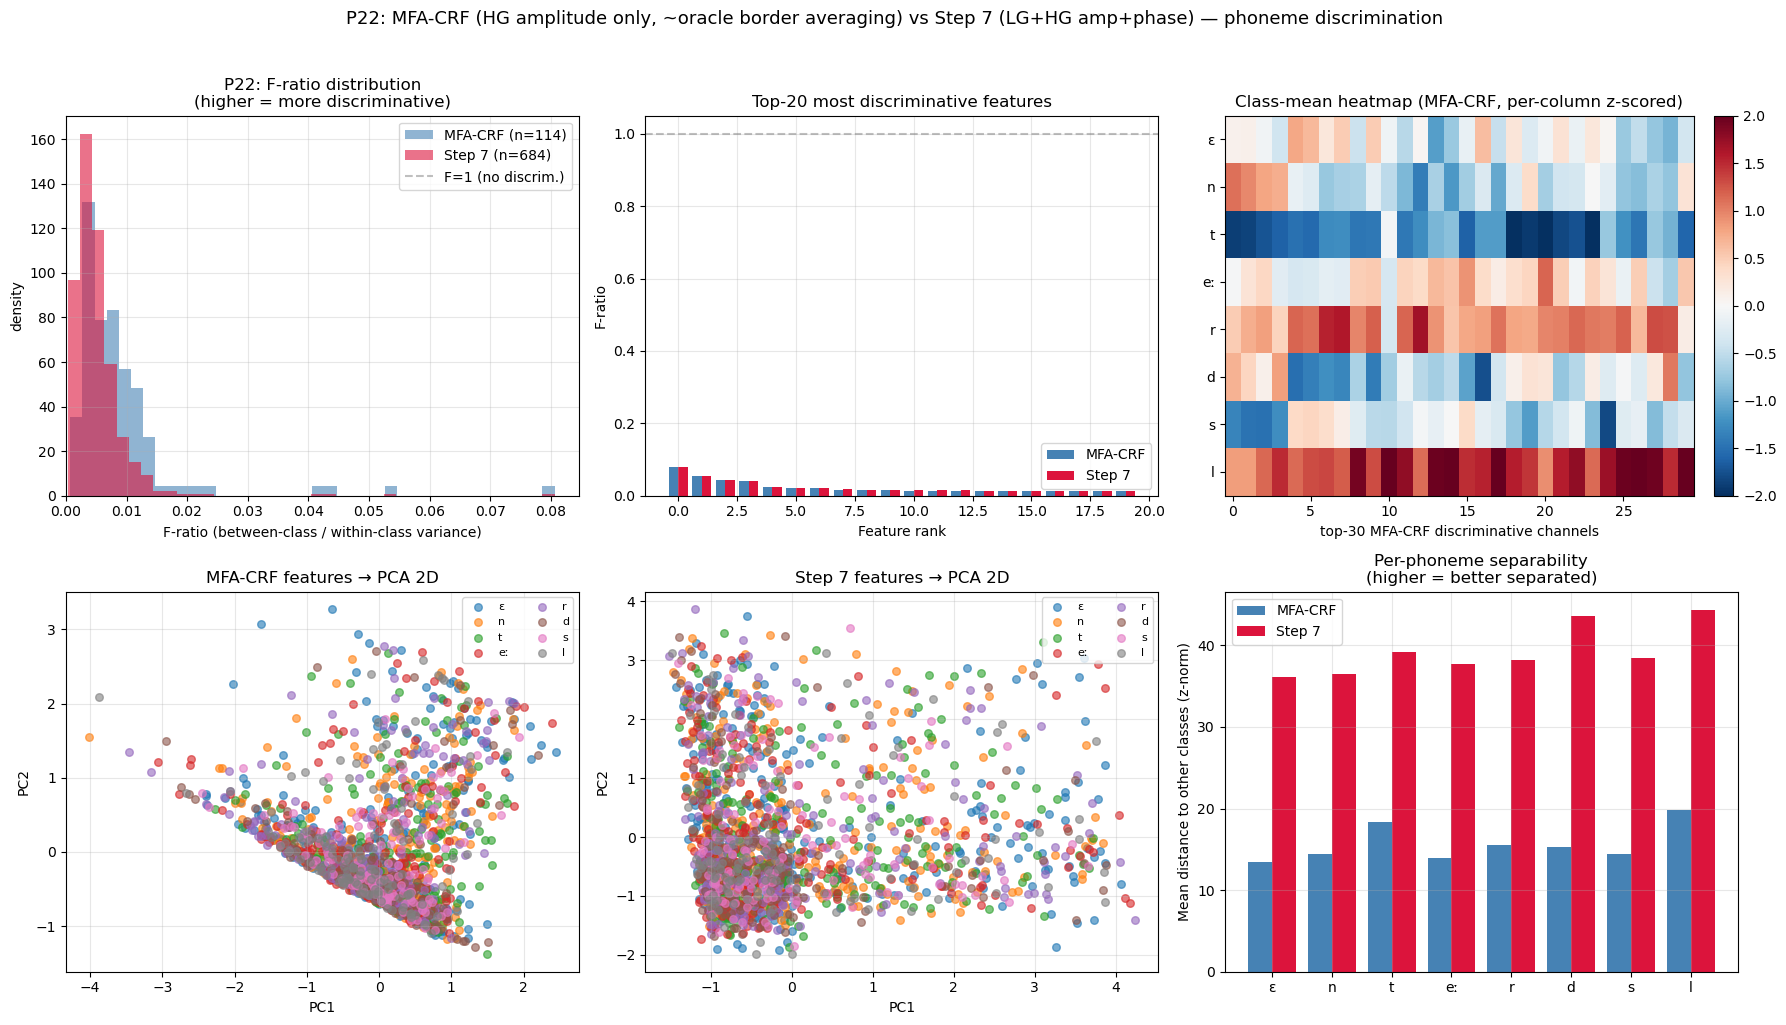


Per-phoneme variance comparison:
 phoneme  n_inst   MFA-CRF mean F   Step 7 mean F   MFA pair-dist  Step7 pair-dist
       ɛ     363            0.001           0.002           13.43            36.13
       n     326            0.004           0.002           14.47            36.55
       t     276            0.013           0.004           18.38            39.21
      eː     260            0.002           0.002           14.00            37.74
       r     212            0.006           0.003           15.58            38.16
       d     142            0.004           0.004           15.30            43.56
       s     136            0.005           0.003           14.40            38.48
       l     127            0.012           0.006           19.78            44.35


In [103]:
# Visual comparison: MFA-CRF features vs Step 7 features
# Per-phoneme statistics, in-class vs between-class variance
# ============================================================
import os, numpy as np
from collections import defaultdict, Counter
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Which patient — P22 is the strongest end-to-end (+3.71) AND was the
# MFA-CRF +13.9 case
pid = 'P22'
TOP_N_PHONEMES = 8

print(f"Analyzing {pid}, top {TOP_N_PHONEMES} phonemes...\n")

# ---- Load raw EEG using the same pipeline conventions ----
raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
    raw_eeg = raw_eeg.T

mfa = load_mfa_alignments(pid)
wd = pipeline.split_result['word_segments_dict'][pid]

# ---- Build features per phoneme instance, both ways ----
# MFA-CRF style: average HG envelope (70-170 Hz, log) within each phoneme's frames
# Step 7 style: average all 6 LG+HG features (amp + phase) within each phoneme's frames
mfa_instances  = []   # list of (phoneme_symbol, feature_vector)  for MFA-CRF
step7_instances = []  # same for Step 7

for sent_idx, sent in enumerate(wd['sentence_list']):
    if not isinstance(sent, dict) or not sent.get('text'): continue
    if sent_idx not in mfa or not mfa[sent_idx]: continue
    s0, s1 = sent['stim_start_idx'], sent['stim_end_idx']
    if s1 > raw_eeg.shape[0]: continue

    eeg_slice = raw_eeg[s0:s1]
    hg_frames   = extract_hg_frames(eeg_slice)                # (T, n_ch)  — MFA-CRF style
    step7_frames = extract_perband_phase_frames(eeg_slice)    # (T, n_ch*6) — Step 7 style
    T_min = min(hg_frames.shape[0], step7_frames.shape[0])

    for ph in mfa[sent_idx]:
        sym = ph['phone']
        k_start = int(np.ceil(ph['start_s'] * FRAME_HZ))
        k_end   = int(np.floor(ph['end_s']  * FRAME_HZ))
        k_start = max(0, k_start); k_end = min(T_min - 1, k_end)
        if k_end < k_start: continue
        mfa_feat   = hg_frames[k_start:k_end + 1].mean(axis=0)
        step7_feat = step7_frames[k_start:k_end + 1].mean(axis=0)
        mfa_instances.append((sym, mfa_feat))
        step7_instances.append((sym, step7_feat))

phoneme_counts = Counter(sym for sym, _ in mfa_instances)
top_phonemes = [p for p, _ in phoneme_counts.most_common(TOP_N_PHONEMES)]
top_phoneme_set = set(top_phonemes)
print(f"Total phoneme instances: {len(mfa_instances)}")
print(f"Top {TOP_N_PHONEMES}: {[(p, phoneme_counts[p]) for p in top_phonemes]}")
print(f"MFA-CRF feature dim: {mfa_instances[0][1].shape[0]}")
print(f"Step 7 feature dim:  {step7_instances[0][1].shape[0]}\n")


# ---- Compute class statistics ----
def gather_by_class(instances, top_set, top_order):
    by_class = defaultdict(list)
    for sym, feat in instances:
        if sym in top_set:
            by_class[sym].append(feat)
    return {sym: np.stack(by_class[sym]) for sym in top_order
            if sym in by_class and len(by_class[sym]) > 1}

def f_ratio_per_feature(class_instances):
    """Standard F-statistic per feature: between-class var / within-class var."""
    class_means = np.stack([arr.mean(axis=0) for arr in class_instances.values()])
    overall_mean = class_means.mean(axis=0)
    between_var = np.mean((class_means - overall_mean) ** 2, axis=0)
    within_var  = np.mean([arr.var(axis=0) for arr in class_instances.values()], axis=0)
    return between_var / (within_var + 1e-9)

mfa_inst   = gather_by_class(mfa_instances,   top_phoneme_set, top_phonemes)
step7_inst = gather_by_class(step7_instances, top_phoneme_set, top_phonemes)

mfa_fratio   = f_ratio_per_feature(mfa_inst)
step7_fratio = f_ratio_per_feature(step7_inst)

print(f"MFA-CRF features  — F-ratio  mean={mfa_fratio.mean():.3f}  "
      f"median={np.median(mfa_fratio):.3f}  max={mfa_fratio.max():.3f}")
print(f"Step 7 features   — F-ratio  mean={step7_fratio.mean():.3f}  "
      f"median={np.median(step7_fratio):.3f}  max={step7_fratio.max():.3f}")


# ---- Visualizations ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: F-ratio distribution per feature
ax = axes[0, 0]
ax.hist(mfa_fratio, bins=40, alpha=0.6, label=f'MFA-CRF (n={len(mfa_fratio)})',
        color='steelblue', density=True)
ax.hist(step7_fratio, bins=40, alpha=0.6, label=f'Step 7 (n={len(step7_fratio)})',
        color='crimson', density=True)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5, label='F=1 (no discrim.)')
ax.set_xlabel('F-ratio (between-class / within-class variance)')
ax.set_ylabel('density')
ax.set_title(f'{pid}: F-ratio distribution\n(higher = more discriminative)')
ax.set_xlim(0, max(mfa_fratio.max(), step7_fratio.max()) * 1.05)
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: Top-20 most discriminative features per setup
ax = axes[0, 1]
top_mfa_fr   = np.sort(mfa_fratio)[-20:][::-1]
top_step7_fr = np.sort(step7_fratio)[-20:][::-1]
x = np.arange(20)
ax.bar(x - 0.2, top_mfa_fr,   width=0.4, color='steelblue', label='MFA-CRF')
ax.bar(x + 0.2, top_step7_fr, width=0.4, color='crimson',   label='Step 7')
ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Feature rank')
ax.set_ylabel('F-ratio')
ax.set_title('Top-20 most discriminative features')
ax.legend(); ax.grid(alpha=0.3)

# Plot 3: Class-mean heatmap for MFA-CRF (phoneme × top-K channels)
ax = axes[0, 2]
top_ch_mfa = np.argsort(mfa_fratio)[-30:][::-1]
heat_mfa = np.stack([mfa_inst[s].mean(axis=0)[top_ch_mfa] for s in top_phonemes
                     if s in mfa_inst])
# Z-score per channel column for visibility
heat_mfa = (heat_mfa - heat_mfa.mean(axis=0)) / (heat_mfa.std(axis=0) + 1e-9)
im = ax.imshow(heat_mfa, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_yticks(range(len(top_phonemes)))
ax.set_yticklabels(top_phonemes)
ax.set_xlabel('top-30 MFA-CRF discriminative channels')
ax.set_title('Class-mean heatmap (MFA-CRF, per-column z-scored)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Plot 4: PCA 2D scatter — MFA-CRF
all_mfa = np.concatenate([mfa_inst[s] for s in top_phonemes if s in mfa_inst])
labels = []
for s in top_phonemes:
    if s in mfa_inst:
        labels.extend([s] * len(mfa_inst[s]))
labels = np.array(labels)
mfa_2d = PCA(n_components=2).fit_transform(all_mfa)

ax = axes[1, 0]
colors = plt.cm.tab10(np.arange(len(top_phonemes)))
for i, sym in enumerate(top_phonemes):
    mask = (labels == sym)
    if mask.sum() == 0: continue
    ax.scatter(mfa_2d[mask, 0], mfa_2d[mask, 1],
               c=[colors[i]], label=sym, alpha=0.6, s=30)
ax.set_title('MFA-CRF features → PCA 2D')
ax.legend(loc='best', ncol=2, fontsize=8); ax.grid(alpha=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# Plot 5: PCA 2D scatter — Step 7
all_step7 = np.concatenate([step7_inst[s] for s in top_phonemes if s in step7_inst])
step7_2d = PCA(n_components=2).fit_transform(all_step7)

ax = axes[1, 1]
for i, sym in enumerate(top_phonemes):
    mask = (labels == sym)
    if mask.sum() == 0: continue
    ax.scatter(step7_2d[mask, 0], step7_2d[mask, 1],
               c=[colors[i]], label=sym, alpha=0.6, s=30)
ax.set_title('Step 7 features → PCA 2D')
ax.legend(loc='best', ncol=2, fontsize=8); ax.grid(alpha=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# Plot 6: Average between-class distance per phoneme
ax = axes[1, 2]
def avg_pairwise_class_distance(class_inst, top):
    means = np.stack([class_inst[s].mean(axis=0) for s in top if s in class_inst])
    # standardize per-feature so scales are comparable across feature sets
    means_n = (means - means.mean(axis=0)) / (means.std(axis=0) + 1e-9)
    n = means_n.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.linalg.norm(means_n[i] - means_n[j])
    return D

D_mfa   = avg_pairwise_class_distance(mfa_inst,   top_phonemes)
D_step7 = avg_pairwise_class_distance(step7_inst, top_phonemes)
x = np.arange(len(top_phonemes))
# Mean distance from each phoneme to all others
avg_dist_mfa   = D_mfa.sum(axis=1)   / (D_mfa.shape[0] - 1)
avg_dist_step7 = D_step7.sum(axis=1) / (D_step7.shape[0] - 1)
ax.bar(x - 0.2, avg_dist_mfa,   width=0.4, color='steelblue', label='MFA-CRF')
ax.bar(x + 0.2, avg_dist_step7, width=0.4, color='crimson',   label='Step 7')
ax.set_xticks(x); ax.set_xticklabels(top_phonemes)
ax.set_ylabel('Mean distance to other classes (z-norm)')
ax.set_title('Per-phoneme separability\n(higher = better separated)')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'{pid}: MFA-CRF (HG amplitude only, ~oracle border averaging) '
             f'vs Step 7 (LG+HG amp+phase) — phoneme discrimination',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# ---- Per-phoneme variance table ----
print(f"\nPer-phoneme variance comparison:")
print(f"{'phoneme':>8}  {'n_inst':>6}  "
      f"{'MFA-CRF mean F':>15}  {'Step 7 mean F':>14}  "
      f"{'MFA pair-dist':>14}  {'Step7 pair-dist':>15}")
for i, sym in enumerate(top_phonemes):
    if sym not in mfa_inst: continue
    n = len(mfa_inst[sym])
    # F-ratio averaged over features that are specific to this class vs rest
    # (per-class F: average within-class variance ratio relative to between)
    others_mfa   = np.concatenate([mfa_inst[s]   for s in top_phonemes
                                     if s != sym and s in mfa_inst])
    others_step7 = np.concatenate([step7_inst[s] for s in top_phonemes
                                     if s != sym and s in step7_inst])
    f_mfa   = ((mfa_inst[sym].mean(axis=0)   - others_mfa.mean(axis=0))**2 /
               (mfa_inst[sym].var(axis=0)   + others_mfa.var(axis=0)   + 1e-9)).mean()
    f_step7 = ((step7_inst[sym].mean(axis=0) - others_step7.mean(axis=0))**2 /
               (step7_inst[sym].var(axis=0) + others_step7.var(axis=0) + 1e-9)).mean()
    print(f"{sym:>8}  {n:>6}  {f_mfa:>15.3f}  {f_step7:>14.3f}  "
          f"{avg_dist_mfa[i]:>14.2f}  {avg_dist_step7[i]:>15.2f}")

PER-FRAME (no MFA averaging):
  MFA-CRF  F-ratio  mean=0.0052  median=0.0035  max=0.0634
  Step 7   F-ratio  mean=0.0025  median=0.0019  max=0.0634

PER-PHONEME averaged (from earlier cell, for reference):
  MFA-CRF  F-ratio  mean=0.0089  median=0.0069
  Step 7   F-ratio  mean=0.0052  median=0.0042

Lift from per-phoneme averaging (median F-ratio):
  MFA-CRF: 2.0×
  Step 7:  2.3×


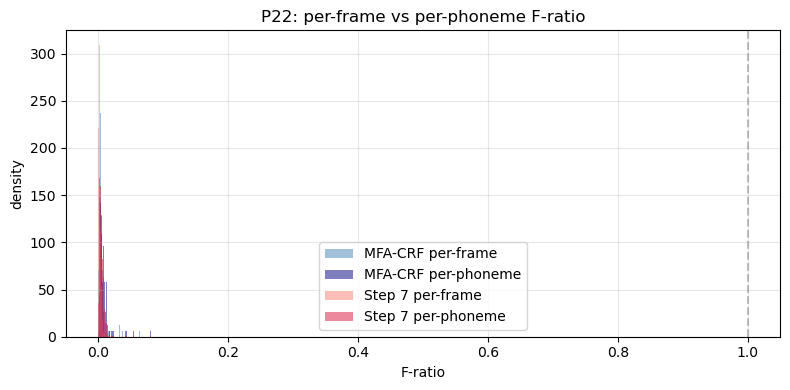

In [104]:
# Sanity check 1: Per-frame F-ratios (no MFA averaging)
# Tells you how much SNR the per-phoneme mean is buying you,
# and therefore an upper bound on what segment pooling can recover.
# ============================================================
def gather_frames_by_class(per_phon_frames, top_set, top_order):
    by_class = defaultdict(list)
    for sym, frames in per_phon_frames:
        if sym in top_set:
            by_class[sym].append(frames)
    return {sym: np.concatenate(by_class[sym], axis=0)
            for sym in top_order
            if sym in by_class and sum(len(a) for a in by_class[sym]) > 1}

mfa_per_phon_frames   = []   # list of (sym, (n_frames, n_ch))
step7_per_phon_frames = []

for sent_idx, sent in enumerate(wd['sentence_list']):
    if not isinstance(sent, dict) or not sent.get('text'): continue
    if sent_idx not in mfa or not mfa[sent_idx]: continue
    s0, s1 = sent['stim_start_idx'], sent['stim_end_idx']
    if s1 > raw_eeg.shape[0]: continue

    eeg_slice    = raw_eeg[s0:s1]
    hg_frames    = extract_hg_frames(eeg_slice)
    step7_frames = extract_perband_phase_frames(eeg_slice)
    T_min = min(hg_frames.shape[0], step7_frames.shape[0])

    for ph in mfa[sent_idx]:
        sym = ph['phone']
        k_start = int(np.ceil(ph['start_s'] * FRAME_HZ))
        k_end   = int(np.floor(ph['end_s']  * FRAME_HZ))
        k_start = max(0, k_start); k_end = min(T_min - 1, k_end)
        if k_end < k_start: continue
        mfa_per_phon_frames.append(  (sym, hg_frames   [k_start:k_end + 1]))
        step7_per_phon_frames.append((sym, step7_frames[k_start:k_end + 1]))

mfa_frames_by_class   = gather_frames_by_class(mfa_per_phon_frames,   top_phoneme_set, top_phonemes)
step7_frames_by_class = gather_frames_by_class(step7_per_phon_frames, top_phoneme_set, top_phonemes)

mfa_frame_fratio   = f_ratio_per_feature(mfa_frames_by_class)
step7_frame_fratio = f_ratio_per_feature(step7_frames_by_class)

print("PER-FRAME (no MFA averaging):")
print(f"  MFA-CRF  F-ratio  mean={mfa_frame_fratio.mean():.4f}  "
      f"median={np.median(mfa_frame_fratio):.4f}  max={mfa_frame_fratio.max():.4f}")
print(f"  Step 7   F-ratio  mean={step7_frame_fratio.mean():.4f}  "
      f"median={np.median(step7_frame_fratio):.4f}  max={step7_frame_fratio.max():.4f}")

print("\nPER-PHONEME averaged (from earlier cell, for reference):")
print(f"  MFA-CRF  F-ratio  mean={mfa_fratio.mean():.4f}  "
      f"median={np.median(mfa_fratio):.4f}")
print(f"  Step 7   F-ratio  mean={step7_fratio.mean():.4f}  "
      f"median={np.median(step7_fratio):.4f}")

print("\nLift from per-phoneme averaging (median F-ratio):")
print(f"  MFA-CRF: {np.median(mfa_fratio)   / max(np.median(mfa_frame_fratio),   1e-9):.1f}×")
print(f"  Step 7:  {np.median(step7_fratio) / max(np.median(step7_frame_fratio), 1e-9):.1f}×")

# Histogram overlay
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, max(mfa_fratio.max(), step7_fratio.max()), 60)
ax.hist(mfa_frame_fratio,   bins=bins, alpha=0.5, color='steelblue', label='MFA-CRF per-frame', density=True)
ax.hist(mfa_fratio,         bins=bins, alpha=0.5, color='navy',      label='MFA-CRF per-phoneme', density=True)
ax.hist(step7_frame_fratio, bins=bins, alpha=0.5, color='salmon',    label='Step 7 per-frame', density=True)
ax.hist(step7_fratio,       bins=bins, alpha=0.5, color='crimson',   label='Step 7 per-phoneme', density=True)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('F-ratio'); ax.set_ylabel('density')
ax.set_title(f'{pid}: per-frame vs per-phoneme F-ratio')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

Feature dims:  MFA-CRF=114  Step7=684

 phoneme   MFA Eucl/√d   Step7 Eucl/√d   MFA cos-dist  Step7 cos-dist
----------------------------------------------------------------------
       ɛ         1.258           1.382          1.228           1.226
       n         1.355           1.397          1.215           1.242
       t         1.721           1.499          1.393           1.316
      eː         1.311           1.443          1.213           1.276
       r         1.459           1.459          1.218           1.255
       d         1.433           1.665          1.274           1.330
       s         1.349           1.471          1.376           1.300
       l         1.853           1.696          1.235           1.288

Mean (across phonemes):
  Eucl/√d :  MFA=1.467  Step7=1.502  ratio=1.02
  cosine  :  MFA=1.269  Step7=1.279  ratio=1.01


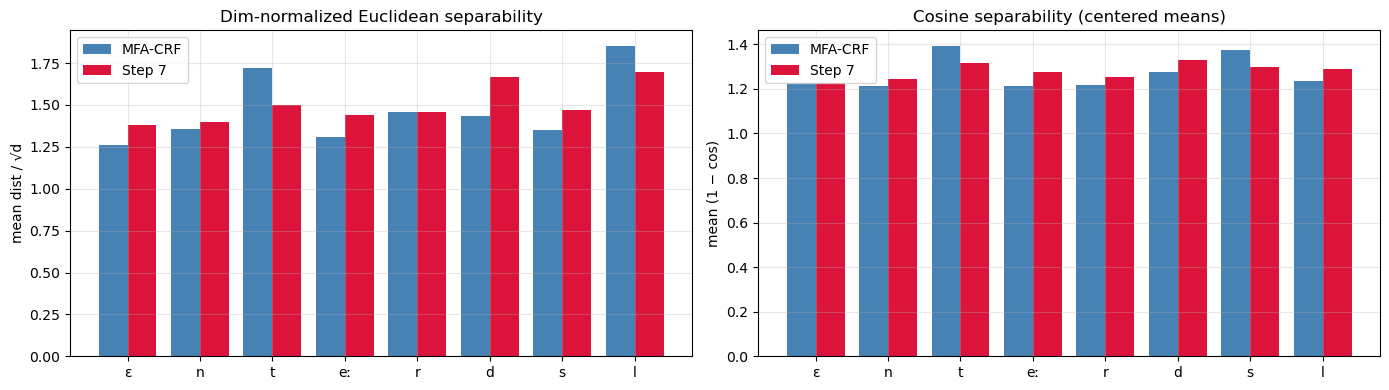

In [105]:
# Sanity check 2: Dim-normalized per-phoneme separability
# Strip out the dimensionality difference and see if MFA-CRF
# and Step 7 actually carry the same per-dim signal.
# ============================================================
d_mfa   = next(iter(mfa_inst.values())).shape[1]
d_step7 = next(iter(step7_inst.values())).shape[1]

# Normalize the existing Euclidean separability by √d
norm_dist_mfa   = avg_dist_mfa   / np.sqrt(d_mfa)
norm_dist_step7 = avg_dist_step7 / np.sqrt(d_step7)

# Cosine distance on centered class means (scale-invariant cross-check)
def cosine_separability(class_inst, top):
    means = np.stack([class_inst[s].mean(axis=0) for s in top if s in class_inst])
    means = means - means.mean(axis=0)            # remove global feature offsets
    norms = np.linalg.norm(means, axis=1, keepdims=True) + 1e-9
    means_u = means / norms
    cos = means_u @ means_u.T                     # (n_class, n_class)
    n = cos.shape[0]
    np.fill_diagonal(cos, 0.0)
    return (1.0 - cos).sum(axis=1) / (n - 1)

cos_mfa   = cosine_separability(mfa_inst,   top_phonemes)
cos_step7 = cosine_separability(step7_inst, top_phonemes)

print(f"Feature dims:  MFA-CRF={d_mfa}  Step7={d_step7}")
print(f"\n{'phoneme':>8}  {'MFA Eucl/√d':>12}  {'Step7 Eucl/√d':>14}  "
      f"{'MFA cos-dist':>13}  {'Step7 cos-dist':>14}")
print("-" * 70)
for i, sym in enumerate(top_phonemes):
    print(f"{sym:>8}  {norm_dist_mfa[i]:>12.3f}  {norm_dist_step7[i]:>14.3f}  "
          f"{cos_mfa[i]:>13.3f}  {cos_step7[i]:>14.3f}")

print(f"\nMean (across phonemes):")
print(f"  Eucl/√d :  MFA={norm_dist_mfa.mean():.3f}  Step7={norm_dist_step7.mean():.3f}  "
      f"ratio={norm_dist_step7.mean()/norm_dist_mfa.mean():.2f}")
print(f"  cosine  :  MFA={cos_mfa.mean():.3f}  Step7={cos_step7.mean():.3f}  "
      f"ratio={cos_step7.mean()/cos_mfa.mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(top_phonemes))
for ax, mfa_vals, step7_vals, title, ylabel in [
    (axes[0], norm_dist_mfa, norm_dist_step7,
     'Dim-normalized Euclidean separability', 'mean dist / √d'),
    (axes[1], cos_mfa, cos_step7,
     'Cosine separability (centered means)',  'mean (1 − cos)'),
]:
    ax.bar(x - 0.2, mfa_vals,   width=0.4, color='steelblue', label='MFA-CRF')
    ax.bar(x + 0.2, step7_vals, width=0.4, color='crimson',   label='Step 7')
    ax.set_xticks(x); ax.set_xticklabels(top_phonemes)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [110]:
# Gold-border ablation across all patients
# ============================================================
import numpy as np, torch
from collections import Counter

# --- PICK ONE result series ------------------------------------------
RESULTS = step1_results        # or step2_results / step5_results / step8_results
SERIES_NAME = 'step1 (CAR+LP12+K10)'
TARGET_PIDS = ['P22', 'P23', 'P26', 'P29']
# ---------------------------------------------------------------------

def run_ablation(pid, res):
    model      = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    sents_te   = res['sents_te']

    if hasattr(model, 'speech_head'):
        print(f"  [{pid}] joint model — skipping (needs bio_idx path)")
        return None

    B_indices = [i for i, t in enumerate(idx_to_tag) if t.startswith('B-')]
    B_syms    = [idx_to_tag[i][2:] for i in B_indices]
    device    = next(model.parameters()).device
    B_idx_t   = torch.tensor(B_indices, device=device)

    def decode_free(s):
        with torch.no_grad():
            path = model.decode(s['X'])
        return [idx_to_tag[int(t)] for t in path]

    def decode_gold_borders(s):
        with torch.no_grad():
            h  = model.encode(s['X'])
            em = model.bio_aux_head(h)
        gold_tags = [idx_to_tag[int(t)] for t in s['tags'].tolist()]
        _, starts, ends = collapse_bio_to_segments(gold_tags)
        out = []
        for k_start, k_end in zip(starts, ends):
            best_local = em[k_start:k_end].mean(dim=0)[B_idx_t].argmax().item()
            sym = B_syms[best_local]
            out.append(f'B-{sym}')
            out.extend([f'I-{sym}'] * (k_end - k_start - 1))
        return out

    def score(pred_bio_lists, gold_bio_lists):
        pred_sents, gold_sents = [], []
        for pb, gb in zip(pred_bio_lists, gold_bio_lists):
            pp, _, _ = collapse_bio_to_segments(pb)
            gp, _, _ = collapse_bio_to_segments(gb)
            pred_sents.append(pp); gold_sents.append(gp)
        all_gold = [ph for ss in gold_sents for ph in ss]
        if not all_gold:
            return {'z': 0.0, 'max_run': 0, 'matches': 0, 'n_pred': 0, 'n_gold': 0}
        cnt = Counter(all_gold); N = sum(cnt.values())
        gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
        runs    = [longest_run_with_shift(p, g)[0]
                   for p, g in zip(pred_sents, gold_sents)]
        max_run = max(runs) if runs else 0
        matches = collect_matches(pred_sents, gold_sents)
        obs     = surprise_score(matches, gold_lp)
        nulls   = perm_null(pred_sents, gold_sents, gold_lp, n_perm=2000)
        z       = float((obs - nulls.mean()) / (nulls.std() + 1e-9))
        return {'z': z, 'max_run': max_run, 'matches': len(matches),
                'n_pred': sum(len(p) for p in pred_sents),
                'n_gold': sum(len(g) for g in gold_sents)}

    gold_bio = [[idx_to_tag[int(t)] for t in s['tags'].tolist()] for s in sents_te]
    free_bio = [decode_free(s)         for s in sents_te]
    gold_bdr = [decode_gold_borders(s) for s in sents_te]

    return {
        'free': score(free_bio, gold_bio),
        'gold': score(gold_bdr, gold_bio),
        'n_sents': len(sents_te),
    }

# Run all patients
print(f"=== Gold-border ablation — {SERIES_NAME} ===\n")
results = {}
for pid in TARGET_PIDS:
    if pid not in RESULTS or RESULTS[pid] is None:
        print(f"[{pid}] no result available — skipping")
        continue
    print(f"[{pid}] decoding...")
    results[pid] = run_ablation(pid, RESULTS[pid])

# Summary table
print(f"\n{'='*82}")
print(f"{'PID':>5}  {'n_sent':>6}  "
      f"{'FREE z':>7}  {'FREE max_run':>12}  {'FREE pred/gold':>15}  "
      f"{'GOLD z':>7}  {'GOLD max_run':>12}  {'Δz':>6}")
print('-' * 82)
for pid, r in results.items():
    if r is None: continue
    f, g = r['free'], r['gold']
    ratio = f"{f['n_pred']}/{f['n_gold']}"
    print(f"{pid:>5}  {r['n_sents']:>6}  "
          f"{f['z']:+7.2f}  {f['max_run']:>12}  {ratio:>15}  "
          f"{g['z']:+7.2f}  {g['max_run']:>12}  {g['z']-f['z']:+6.2f}")

# Mean Δz across patients with valid results
dzs = [r['gold']['z'] - r['free']['z'] for r in results.values() if r is not None]
if dzs:
    print(f"\nMean Δz from oracle borders: {np.mean(dzs):+.2f}  "
          f"(min {min(dzs):+.2f}, max {max(dzs):+.2f})")

=== Gold-border ablation — step1 (CAR+LP12+K10) ===

[P22] decoding...
[P23] decoding...
[P26] decoding...
[P29] decoding...

  PID  n_sent   FREE z  FREE max_run   FREE pred/gold   GOLD z  GOLD max_run      Δz
----------------------------------------------------------------------------------
  P22      16    +0.60             3          329/557    +1.40             3   +0.80
  P23      15    +1.13             3          334/516    +0.38             3   -0.75
  P26      12    +0.95             3          275/382    +2.37             3   +1.42
  P29      17    +3.13             3          287/503    +0.47             3   -2.66

Mean Δz from oracle borders: -0.30  (min -2.66, max +1.42)


In [121]:
# ============================================================
# 4-patient CV on winning config: mo=5, ss=1, frames=0-300, LDA-shrink
# ============================================================
import os, time, warnings, numpy as np
from collections import Counter, defaultdict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from extract_features import extractHG, stackFeatures

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

TARGET_PIDS   = ['P22', 'P23', 'P26', 'P29']
SPLIT_OFFSETS = [0, 1, 2, 3, 4, 5]
MO, SS        = 5, 1
MN, MX        = 0, 300
MARGIN        = MO * SS

def build_stacked(pid, test_offset):
    raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
        raw_eeg = raw_eeg.T
    wd  = pipeline.split_result['word_segments_dict'][pid]
    mfa = load_mfa_alignments(pid)
    all_real = [i for i, s in enumerate(wd['sentence_list'])
                if isinstance(s, dict) and s.get('text')]
    test_sent_ids = set(all_real[test_offset::6])
    win_samp, shift_samp = int(EEG_SR*0.015), int(EEG_SR*0.005)
    out = {'train': defaultdict(list), 'test': defaultdict(list)}
    for sent_idx in all_real:
        if sent_idx not in mfa or not mfa[sent_idx]: continue
        s = wd['sentence_list'][sent_idx]
        s0, s1 = s['stim_start_idx'], s['stim_end_idx']
        if s1 > raw_eeg.shape[0]: continue
        ext = extractHG(raw_eeg[s0:s1], EEG_SR, windowLength=0.015,
                        frameshift=0.005, smoothing_hz=10.0).astype(np.float32)
        if ext.shape[0] < 2*MARGIN + 1: continue
        stk = stackFeatures(ext, modelOrder=MO, stepSize=SS)
        T_stk = stk.shape[0]
        split = 'test' if sent_idx in test_sent_ids else 'train'
        for ph in mfa[sent_idx]:
            k_s = int(np.ceil((ph['start_s']*EEG_SR - win_samp/2) / shift_samp))
            k_e = int(np.floor((ph['end_s']  *EEG_SR - win_samp/2) / shift_samp))
            n_fr = k_e - k_s + 1
            if n_fr < MN or n_fr > MX: continue
            ks = max(0, k_s - MARGIN); ke = min(T_stk - 1, k_e - MARGIN)
            if ke < ks: continue
            out[split]['X'].append(stk[ks:ke+1].mean(axis=0))
            out[split]['y'].append(ph['phone'])
            out[split]['sent'].append(sent_idx)
    return {sp: {'X': np.array(out[sp]['X']),
                 'y': list(out[sp]['y']),
                 'sent': list(out[sp]['sent'])} for sp in ('train', 'test')}

def fit_score_lda(data):
    X_tr, y_tr = data['train']['X'], data['train']['y']
    X_te, y_te = data['test']['X'],  data['test']['y']
    sent_te    = data['test']['sent']
    if len(X_tr) == 0 or len(X_te) == 0: return None
    keep = [i for i, p in enumerate(y_te) if p in set(y_tr)]
    if not keep: return None
    X_te = X_te[keep]; y_te = [y_te[i] for i in keep]; sent_te = [sent_te[i] for i in keep]
    sc  = StandardScaler().fit(X_tr)
    clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    clf.fit(sc.transform(X_tr), y_tr)
    y_pred = clf.predict(sc.transform(X_te))
    by_sent = defaultdict(lambda: {'pred': [], 'gold': []})
    for s, p, g in zip(sent_te, y_pred, y_te):
        by_sent[s]['pred'].append(p); by_sent[s]['gold'].append(g)
    pred_sents = [v['pred'] for v in by_sent.values()]
    gold_sents = [v['gold'] for v in by_sent.values()]
    all_gold = [ph for ss in gold_sents for ph in ss]
    if not all_gold: return None
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    runs = [longest_run_with_shift(p, g)[0] for p, g in zip(pred_sents, gold_sents)]
    max_run = max(runs) if runs else 0
    matches = collect_matches(pred_sents, gold_sents)
    obs = surprise_score(matches, gold_lp)
    nulls = perm_null(pred_sents, gold_sents, gold_lp, n_perm=2000)
    return {'z': float((obs - nulls.mean()) / (nulls.std() + 1e-9)),
            'max_run': max_run, 'matches': len(matches),
            'n_tr': len(X_tr), 'n_te': len(X_te)}

print(f"=== 4-patient 6-fold CV: mo={MO}, ss={SS}, frames={MN}-{MX}, LDA-shrink ===\n")
header = (f"{'PID':>5}  {'n_tr':>5}  " +
          "  ".join(f"off={o}".rjust(10) for o in SPLIT_OFFSETS) +
          f"  {'mean z':>7}  {'std z':>6}  {'mean mr':>8}  {'max single z':>12}")
print(header); print('-' * len(header))

t0 = time.time()
summary = {}
for pid in TARGET_PIDS:
    cells, zs, mrs, n_tr_last = [], [], [], 0
    for off in SPLIT_OFFSETS:
        data = build_stacked(pid, off)
        r = fit_score_lda(data)
        if r is None:
            cells.append(f"{'--':>10}")
        else:
            cells.append(f"{r['z']:+5.2f}/{r['max_run']}".rjust(10))
            zs.append(r['z']); mrs.append(r['max_run']); n_tr_last = r['n_tr']
    if zs:
        m, s, mm, mx_z = np.mean(zs), np.std(zs), np.mean(mrs), max(zs)
        summary[pid] = (m, s, mm, mx_z)
        print(f"{pid:>5}  {n_tr_last:>5}  " + "  ".join(cells) +
              f"  {m:+7.2f}  {s:6.2f}  {mm:8.1f}  {mx_z:+12.2f}")
    else:
        print(f"{pid:>5}  no valid folds")

print(f"\nTotal time: {time.time()-t0:.0f}s")
print(f"\nHonest per-patient summary:")
for pid, (m, s, mm, mx_z) in summary.items():
    print(f"  {pid}:  mean z = {m:+.2f} ± {s:.2f},  mean max_run = {mm:.1f},  "
          f"best single split z = {mx_z:+.2f}")

=== 4-patient 6-fold CV: mo=5, ss=1, frames=0-300, LDA-shrink ===

  PID   n_tr       off=0       off=1       off=2       off=3       off=4       off=5   mean z   std z   mean mr  max single z
-----------------------------------------------------------------------------------------------------------------------------
  P22   2722     +4.06/4     +5.00/5     +0.87/3     -0.74/2     +2.83/3     +1.47/3    +2.25    1.94       3.3         +5.00
  P23   2772     +0.33/3     -0.80/2     +0.64/3     +1.74/3     -0.61/2     +0.96/3    +0.38    0.88       2.7         +1.74
  P26   2014     -0.57/2     +0.99/3     -0.65/2     -0.57/2     -0.59/2     +1.79/3    +0.07    0.97       2.3         +1.79
  P29   2887     +0.13/3     -0.80/2     +0.90/3     -0.91/2     -0.67/2     -0.77/2    -0.35    0.66       2.3         +0.90

Total time: 149s

Honest per-patient summary:
  P22:  mean z = +2.25 ± 1.94,  mean max_run = 3.3,  best single split z = +5.00
  P23:  mean z = +0.38 ± 0.88,  mean max_run = 2.

In [ ]:
# Run the real MFA-CRF feature builder for one patient
run_config = {'patient_range': (22, 22)}
mfa_train, mfa_test = build_mfa_features(pipeline, run_config)
# mfa_train['features'] is now a list of per-phoneme (T_frames, n_channels) arrays
# mfa_train['phoneme_labels'] is the corresponding list of phoneme symbols
# Average each entry to one vector per phoneme:
mfa_crf_instances = [
    (lbl, feat.mean(axis=0))
    for feat, lbl in zip(mfa_train['features'] + mfa_test['features'],
                         mfa_train['phoneme_labels'] + mfa_test['phoneme_labels'])
]

In [95]:
#BiLSTM emission backbone + CRF (no O)

class JointBiLSTM_BIO_CRF(nn.Module):
    """Same as BiLSTM_BIO_CRF but with an additional speech_head trained on
       ALL frames. BIO/manner/place heads only see frames inside phoneme
       intervals (selected via bio_idx)."""
    def __init__(self, n_in, n_phon, n_manner=5, n_place=8,
                 lstm_hidden=128, lstm_layers=2, dropout=0.3,
                 transition_mask=None, transition_init=None, n_tags=None):
        super().__init__()
        self.n_tags = n_tags
        self.proj = nn.Sequential(
            nn.Linear(n_in, lstm_hidden * 2), nn.GELU(), nn.Dropout(dropout))
        self.lstm = nn.LSTM(lstm_hidden * 2, lstm_hidden,
                            num_layers=lstm_layers,
                            dropout=dropout if lstm_layers > 1 else 0.0,
                            bidirectional=True, batch_first=False)
        self.drop = nn.Dropout(dropout)
        self.bio_head     = nn.Linear(lstm_hidden * 2, n_tags)
        self.bio_aux_head = nn.Linear(lstm_hidden * 2, n_tags)
        self.manner_head  = nn.Linear(lstm_hidden * 2, n_manner)
        self.place_head   = nn.Linear(lstm_hidden * 2, n_place)
        self.speech_head  = nn.Linear(lstm_hidden * 2, 2)        # NEW
        self.crf = LinearChainCRF(n_tags, transition_mask, transition_init)

    def encode(self, x):
        h, _ = self.lstm(self.proj(x).unsqueeze(1))
        return self.drop(h.squeeze(1))                            # (T_full, 2H)

    def loss(self, x_full, speech_labels, bio_idx, tags, manner, place,
             lam_speech=0.5, lam_bio_ce=0.5, lam_manner=0.3, lam_place=0.1,
             ce_weights=None, speech_weights=None):
        h_full   = self.encode(x_full)                            # (T_full, 2H)
        speech_l = F.cross_entropy(self.speech_head(h_full),
                                   speech_labels, weight=speech_weights)

        h_bio = h_full[bio_idx]                                   # (T_bio, 2H)
        bio_em = self.bio_head(h_bio)
        crf_nll = self.crf.neg_log_likelihood(bio_em, tags) / max(h_bio.size(0), 1)
        bio_ce = F.cross_entropy(self.bio_aux_head(h_bio), tags, weight=ce_weights)

        valid_m = manner >= 0
        mn_loss = (F.cross_entropy(self.manner_head(h_bio)[valid_m], manner[valid_m])
                   if valid_m.sum() > 0 else torch.tensor(0., device=x_full.device))
        valid_p = place >= 0
        pl_loss = (F.cross_entropy(self.place_head(h_bio)[valid_p], place[valid_p])
                   if valid_p.sum() > 0 else torch.tensor(0., device=x_full.device))

        total = (crf_nll + lam_bio_ce * bio_ce + lam_manner * mn_loss
                 + lam_place * pl_loss + lam_speech * speech_l)
        return total, {
            'crf':    float(crf_nll.item()),
            'bio_ce': float(bio_ce.item()),
            'mn':     float(mn_loss.item()),
            'pl':     float(pl_loss.item()),
            'speech': float(speech_l.item()),
        }

    @torch.no_grad()
    def decode(self, x_full, bio_idx):
        """At inference, return Viterbi path over the speech frames
           (selected via bio_idx — gold speech mask in eval, predicted at deploy)."""
        h_full = self.encode(x_full)
        h_bio  = h_full[bio_idx]
        return self.crf.viterbi(self.bio_head(h_bio))

    @torch.no_grad()
    def predict_speech(self, x_full):
        """Per-frame speech probability for deployment use."""
        return F.softmax(self.speech_head(self.encode(x_full)), dim=-1)


def make_joint_model(pid, joint_datasets, saved_models,
                     lstm_hidden=128, lstm_layers=2, dropout=0.3):
    fd = joint_datasets[pid]
    state = saved_models[pid]
    cls_to_i = state['cls_to_i']
    bg_lp = state['bg_lp']
    pm_arr = np.asarray(state['phone_to_manner']).astype(int)
    n_in = fd['train'][0]['X'].shape[1]
    n_phon = len(cls_to_i)
    n_manner = int(pm_arr.max()) + 1
    n_place = 8

    tag_to_idx, idx_to_tag, n_tags = build_tag_index_noO(cls_to_i)
    trans_mask = build_transition_mask_noO(idx_to_tag)
    trans_init = init_transition_matrix_noO(idx_to_tag, bg_lp, cls_to_i)

    model = JointBiLSTM_BIO_CRF(
        n_in=n_in, n_phon=n_phon, n_manner=n_manner, n_place=n_place,
        lstm_hidden=lstm_hidden, lstm_layers=lstm_layers, dropout=dropout,
        transition_mask=trans_mask, transition_init=trans_init, n_tags=n_tags)
    return model, tag_to_idx, idx_to_tag


# Quick sanity check
for pid in TARGET_PIDS:
    if pid not in joint_datasets: continue
    m, _, _ = make_joint_model(pid, joint_datasets, saved_models)
    print(f"{pid}: params={sum(p.numel() for p in m.parameters())/1e6:.2f}M  n_tags={m.n_tags}")

P22: params=1.16M  n_tags=82
P23: params=1.21M  n_tags=82
P26: params=1.09M  n_tags=70
P29: params=1.08M  n_tags=78


In [43]:
# # GPU training + mid-phoneme mixup

# import time
# import torch.optim as optim

# EPOCHS         = 40
# LR             = 2.5e-4
# WEIGHT_DECAY   = 1e-3
# EARLY_STOP_PATIENCE = 6      # stop if no improvement for 8 epochs
# LAM_MANNER     = 0.3
# LAM_PLACE      = 0.1
# LAM_BIO_CE     = 0.5
# B_BOOST        = 0.0      # O is gone; usually unneeded
# GRAD_CLIP      = 5.0
# MIN_SENT_FRAMES = 30

# # augmentation
# P_AUG          = 0.5      # prob of augmenting a sentence in a step
# AUG_FRAC       = 0.2      # fraction of mid-phoneme frames perturbed
# MIX_RATIO      = 0.8      # anchor weight
# MIN_PHON_LEN_FOR_AUG = 6  # frames; phoneme must be at least this long


# def split_into_sentences_v2(split_dict, tag_to_idx):
#     sents = []
#     sidx = split_dict['sent_idx']
#     boundaries = np.where(np.diff(sidx, prepend=sidx[0] - 1) != 0)[0].tolist() \
#                  + [len(sidx)]
#     n_oov_total = 0
#     for k in range(len(boundaries) - 1):
#         s, e = boundaries[k], boundaries[k + 1]
#         if e - s < MIN_SENT_FRAMES: continue
#         bio_str_full = split_dict['bio'][s:e]
#         # filter frames whose tag is OOV (test phoneme not in train vocab)
#         keep_local = np.array([t in tag_to_idx for t in bio_str_full])
#         n_oov_total += int((~keep_local).sum())
#         if keep_local.sum() < MIN_SENT_FRAMES: continue

#         bio_str = bio_str_full[keep_local]
#         tags = np.array([tag_to_idx[t] for t in bio_str], dtype=np.int64)

#         # mid_phoneme mask (same as before, on the kept slice)
#         mid_mask = np.zeros(len(tags), dtype=bool)
#         i = 0
#         while i < len(bio_str):
#             if bio_str[i].startswith('B-'):
#                 ph = bio_str[i][2:]
#                 j = i + 1
#                 while j < len(bio_str) and bio_str[j] == f'I-{ph}':
#                     j += 1
#                 if (j - i) >= MIN_PHON_LEN_FOR_AUG:
#                     margin = 2
#                     mid_mask[i + margin: j - margin] = True
#                 i = j
#             else:
#                 i += 1

#         X_full      = split_dict['X'][s:e]
#         manner_full = split_dict['manner'][s:e]
#         place_full  = split_dict['place'][s:e]
#         sents.append({
#             'X':      torch.from_numpy(X_full[keep_local]).float(),
#             'tags':   torch.from_numpy(tags),
#             'manner': torch.from_numpy(manner_full[keep_local]),
#             'place':  torch.from_numpy(place_full[keep_local]),
#             'mid':    torch.from_numpy(mid_mask),
#             'sent_idx': int(sidx[s]),
#         })
#     if n_oov_total > 0:
#         print(f"  dropped {n_oov_total} frames with OOV phonemes")
#     return sents

# def fit_mu_sd(sents):
#     Xall = torch.cat([s['X'] for s in sents], dim=0).numpy()
#     return Xall.mean(0), Xall.std(0)

# def standardize(sents, mu, sd):
#     sd_safe = np.where(sd < 1e-6, 1.0, sd)
#     mu_t = torch.from_numpy(mu).float()
#     sd_t = torch.from_numpy(sd_safe).float()
#     for s in sents:
#         s['X'] = (s['X'] - mu_t) / sd_t

# def to_device(sents, device):
#     for s in sents:
#         for k in ('X', 'tags', 'manner', 'place', 'mid'):
#             s[k] = s[k].to(device)

# def make_ce_weights(sents_tr, n_tags, device):
#     """Class weights for the BIO direct-CE loss: inverse frequency, clamped."""
#     cnt = torch.zeros(n_tags)
#     for s in sents_tr:
#         for t in s['tags'].cpu().tolist():
#             cnt[t] += 1
#     cnt = cnt.clamp(min=1.0)
#     w = (cnt.sum() / (n_tags * cnt))
#     w = w.clamp(min=0.2, max=5.0)
#     return w.to(device)

# def augment_sentence(s_anchor, partner_pool, p_aug, aug_frac, mix_ratio, rng):
#     """Returns (X_maybe_augmented, tags_unchanged)."""
#     if rng.random() > p_aug or s_anchor['mid'].sum() == 0:
#         return s_anchor['X']
#     mid_idx = s_anchor['mid'].nonzero(as_tuple=False).flatten()
#     n_perturb = max(1, int(len(mid_idx) * aug_frac))
#     perm = mid_idx[torch.randperm(len(mid_idx), device=mid_idx.device)[:n_perturb]]
#     partner = partner_pool[rng.integers(0, len(partner_pool))]
#     # pick random frames from partner (any frames, length-matched via wrap)
#     if partner['X'].size(0) == 0:
#         return s_anchor['X']
#     p_idx = torch.randint(0, partner['X'].size(0), (n_perturb,),
#                           device=partner['X'].device)
#     X = s_anchor['X'].clone()
#     X[perm] = mix_ratio * X[perm] + (1.0 - mix_ratio) * partner['X'][p_idx]
#     return X

# def evaluate_for_selection(model, sents_te, idx_to_tag):
#     model.eval()
#     correct = total = 0
#     pred_symbols = set()
#     n_pred = 0
#     with torch.no_grad():
#         for s in sents_te:
#             path = model.decode(s['X'])
#             tg = s['tags'].tolist()
#             for p, t in zip(path, tg):
#                 correct += (p == t); total += 1
#             for p in path:
#                 tag = idx_to_tag[int(p)]
#                 if tag.startswith('B-'):
#                     pred_symbols.add(tag[2:])
#                     n_pred += 1
#     tag_acc = correct / max(total, 1)
#     # Relaxed: 3 unique phonemes → factor 1.0 (was 5)
#     diversity = min(1.0, len(pred_symbols) / 3.0)
#     # Relaxed: 0.5× gold coverage already counts as full
#     coverage_ratio = min(1.0, n_pred / max(1, total / 34))   # 34 = 2× phoneme len
#     composite = tag_acc * diversity * coverage_ratio
#     return composite, tag_acc, len(pred_symbols), n_pred

# def train_v2(pid, frame_datasets_v2, saved_models, epochs=EPOCHS, **arch):
#     fd = frame_datasets_v2[pid]
#     if fd['train'] is None or fd['test'] is None:
#         return None
#     model, tag_to_idx, idx_to_tag = make_model_v2(
#         pid, frame_datasets_v2, saved_models, **arch)
#     model = model.to(DEVICE)

#     sents_tr = split_into_sentences_v2(fd['train'], tag_to_idx)
#     sents_te = split_into_sentences_v2(fd['test'],  tag_to_idx)
#     if not sents_tr:
#         return None
#     mu, sd = fit_mu_sd(sents_tr)
#     standardize(sents_tr, mu, sd); standardize(sents_te, mu, sd)
#     to_device(sents_tr, DEVICE); to_device(sents_te, DEVICE)

#     ce_weights = make_ce_weights(sents_tr, model.n_tags, DEVICE)

#     opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
#     sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

#     rng = np.random.default_rng(0)
#     best_acc, best_state = 0.0, None
#     no_improve = 0
#     stopped_early = False

#     for ep in range(epochs):
#         model.train()
#         perm = rng.permutation(len(sents_tr))
#         losses = {'total': 0, 'crf': 0, 'bio_ce': 0, 'mn': 0, 'pl': 0}
#         for idx in perm:
#             s = sents_tr[idx]
#             X_aug = augment_sentence(s, sents_tr, P_AUG, AUG_FRAC, MIX_RATIO, rng)
#             opt.zero_grad()
#             loss, parts = model.loss(
#                 X_aug, s['tags'], s['manner'], s['place'],
#                 lam_manner=LAM_MANNER, lam_place=LAM_PLACE,
#                 lam_bio_ce=LAM_BIO_CE, b_boost=B_BOOST,
#                 ce_weights=ce_weights)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
#             opt.step()
#             losses['total'] += float(loss.item())
#             for k in ('crf', 'bio_ce', 'mn', 'pl'):
#                 losses[k] += parts[k]
#         sched.step()

#         if (ep + 1) % 5 == 0 or ep == 0:
#             score, tag_acc, n_uniq, n_pred = evaluate_for_selection(
#                 model, sents_te, idx_to_tag)
#             if score > best_acc and ep >= 5:
#                 best_acc = score
#                 best_state = {k: v.detach().cpu().clone()
#                               for k, v in model.state_dict().items()}
#                 no_improve = 0
#             else:
#                 no_improve += 1

#             n = len(sents_tr)
#             print(f"  [{pid}] ep{ep+1:3d} "
#                   f"loss={losses['total']/n:6.2f} crf={losses['crf']/n:5.2f} "
#                   f"bio_ce={losses['bio_ce']/n:5.2f} "
#                   f"mn={losses['mn']/n:.2f} pl={losses['pl']/n:.2f}  "
#                   f"score={score:.3f} tag_acc={tag_acc:.3f} "
#                   f"n_uniq={n_uniq} n_pred={n_pred} "
#                   f"(best_score={best_acc:.3f})")

#             if no_improve >= EARLY_STOP_PATIENCE:
#                 print(f"  [{pid}] early stopping at ep {ep+1}")
#                 stopped_early = True
#                 break

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     # Save to disk for inspection
#     import os, pickle
#     os.makedirs('bio_models', exist_ok=True)
#     save_path = f'bio_models/{pid}_biocrf_v2.pkl'
#     with open(save_path, 'wb') as f:
#         pickle.dump({
#             'state_dict': model.state_dict(),
#             'mu': mu, 'sd': sd,
#             'tag_to_idx': tag_to_idx, 'idx_to_tag': idx_to_tag,
#             'arch': dict(lstm_hidden=128, lstm_layers=2,
#                          lstm_dropout=0.3, head_dropout=0.3),
#             'best_acc': best_acc,
#             'pid': pid,
#         }, f)
#     print(f"  [{pid}] saved to {save_path}")

#     return {
#         'model': model, 'mu': mu, 'sd': sd,
#         'tag_to_idx': tag_to_idx, 'idx_to_tag': idx_to_tag,
#         'sents_tr': sents_tr, 'sents_te': sents_te,
#         'best_acc': best_acc,
#     }
    
# bio_results_v2 = {}
# for pid in TARGET_PIDS:
#     if pid not in frame_datasets_v2 or frame_datasets_v2[pid]['train'] is None:
#         continue
#     print(f"\n=== Training {pid} ===")
#     t0 = time.time()
#     bio_results_v2[pid] = train_v2(
#         pid, frame_datasets_v2, saved_models, epochs=EPOCHS,
#         lstm_hidden=128, lstm_layers=2, lstm_dropout=0.3, head_dropout=0.3)
#     if bio_results_v2[pid]:
#         print(f"  [{pid}] done in {time.time() - t0:.1f}s")


=== Training P22 ===
  [P22] ep  1 loss=  4.07 crf= 1.29 bio_ce= 4.28 mn=1.57 pl=1.65  score=0.000 tag_acc=0.058 n_uniq=0 n_pred=0 (best_score=0.000)
  [P22] ep  5 loss=  2.97 crf= 0.41 bio_ce= 4.00 mn=1.42 pl=1.35  score=0.003 tag_acc=0.081 n_uniq=4 n_pred=11 (best_score=0.000)
  [P22] ep 10 loss=  2.54 crf= 0.33 bio_ce= 3.49 mn=1.14 pl=1.20  score=0.050 tag_acc=0.111 n_uniq=18 n_pred=131 (best_score=0.050)
  [P22] ep 15 loss=  1.91 crf= 0.25 bio_ce= 2.68 mn=0.76 pl=0.96  score=0.070 tag_acc=0.086 n_uniq=24 n_pred=238 (best_score=0.070)
  [P22] ep 20 loss=  1.38 crf= 0.19 bio_ce= 1.95 mn=0.49 pl=0.73  score=0.099 tag_acc=0.104 n_uniq=27 n_pred=277 (best_score=0.099)
  [P22] ep 25 loss=  1.08 crf= 0.16 bio_ce= 1.51 mn=0.36 pl=0.59  score=0.106 tag_acc=0.106 n_uniq=28 n_pred=320 (best_score=0.106)
  [P22] ep 30 loss=  0.93 crf= 0.15 bio_ce= 1.30 mn=0.30 pl=0.51  score=0.120 tag_acc=0.120 n_uniq=24 n_pred=315 (best_score=0.120)
  [P22] ep 35 loss=  0.87 crf= 0.14 bio_ce= 1.21 mn=0.27 pl

In [83]:
# Joint training
# Make sure: joint_datasets is populated, JointBiLSTM_BIO_CRF is defined,
# build_tag_index_noO / build_transition_mask_noO / init_transition_matrix_noO
# / LinearChainCRF are defined (from the v2 cells), and make_joint_model exists.
# ============================================================
import time
import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

EPOCHS              = 40
LR                  = 3e-4
WEIGHT_DECAY        = 1e-3
LAM_SPEECH          = 0.5
LAM_MANNER          = 0.3
LAM_PLACE           = 0.1
LAM_BIO_CE          = 0.5
EARLY_STOP_PATIENCE = 6
MIN_SENT_FRAMES     = 30


def prepare_joint_sentences(sents, tag_to_idx):
    out = []
    n_oov = 0
    for s in sents:
        if s['X'].size(0) < MIN_SENT_FRAMES: continue
        bio_strs = s['bio_strs']
        keep_local = np.array([t in tag_to_idx for t in bio_strs])
        n_oov += int((~keep_local).sum())
        if keep_local.sum() < 11: continue
        bio_idx_filt = s['bio_idx'][torch.from_numpy(keep_local)]
        tags = np.array([tag_to_idx[t] for t in bio_strs[keep_local]],
                        dtype=np.int64)
        out.append({
            'X':        s['X'],
            'speech':   s['speech'],
            'bio_idx':  bio_idx_filt,
            'tags':     torch.from_numpy(tags),
            'manner':   s['manner'][torch.from_numpy(keep_local)],
            'place':    s['place'][torch.from_numpy(keep_local)],
            'sent_idx': s['sent_idx'],
        })
    if n_oov: print(f"  dropped {n_oov} OOV-tag frames")
    return out


def fit_mu_sd_joint(sents):
    Xall = torch.cat([s['X'].cpu() for s in sents], dim=0).numpy()
    return Xall.mean(0), Xall.std(0)

def standardize_joint(sents, mu, sd):
    sd_safe = np.where(sd < 1e-6, 1.0, sd)
    for s in sents:
        device = s['X'].device
        mu_t = torch.from_numpy(mu).float().to(device)
        sd_t = torch.from_numpy(sd_safe).float().to(device)
        s['X'] = (s['X'] - mu_t) / sd_t

def to_device_joint(sents, device):
    for s in sents:
        for k in ('X', 'speech', 'bio_idx', 'tags', 'manner', 'place'):
            s[k] = s[k].to(device)


def make_bio_ce_weights(sents_tr, n_tags, device):
    cnt = torch.zeros(n_tags)
    for s in sents_tr:
        for t in s['tags'].cpu().tolist(): cnt[t] += 1
    cnt = cnt.clamp(min=1.0)
    w = (cnt.sum() / (n_tags * cnt)).clamp(min=0.2, max=5.0)
    return w.to(device)

def make_speech_weights(sents_tr, device):
    all_sp = torch.cat([s['speech'].cpu() for s in sents_tr])
    n0 = (all_sp == 0).sum().item(); n1 = (all_sp == 1).sum().item()
    return torch.tensor([n1/(n0+n1), n0/(n0+n1)],
                        dtype=torch.float32, device=device)


def evaluate_joint(model, sents_te, idx_to_tag):
    model.eval()
    correct = total = 0
    pred_symbols = set(); n_pred = 0
    sp_correct = sp_total = 0
    with torch.no_grad():
        for s in sents_te:
            sp_pred = model.predict_speech(s['X']).argmax(-1)
            sp_correct += (sp_pred == s['speech']).sum().item()
            sp_total   += s['speech'].numel()

            path = model.decode(s['X'], s['bio_idx'])
            tg = s['tags'].tolist()
            for p, t in zip(path, tg):
                correct += (p == t); total += 1
            for p in path:
                tag = idx_to_tag[int(p)]
                if tag.startswith('B-'):
                    pred_symbols.add(tag[2:]); n_pred += 1
    tag_acc = correct / max(total, 1)
    sp_acc  = sp_correct / max(sp_total, 1)
    diversity = min(1.0, len(pred_symbols) / 3.0)
    coverage  = min(1.0, n_pred / max(1, total / 34))
    composite = tag_acc * diversity * coverage
    return {'composite': composite, 'tag_acc': tag_acc, 'speech_acc': sp_acc,
            'n_uniq': len(pred_symbols), 'n_pred': n_pred}


def train_joint(pid, joint_datasets, saved_models, epochs=EPOCHS, **arch):
    model, tag_to_idx, idx_to_tag = make_joint_model(
        pid, joint_datasets, saved_models, **arch)
    model = model.to(DEVICE)

    sents_tr = prepare_joint_sentences(joint_datasets[pid]['train'], tag_to_idx)
    sents_te = prepare_joint_sentences(joint_datasets[pid]['test'],  tag_to_idx)
    if not sents_tr: return None
    mu, sd = fit_mu_sd_joint(sents_tr)
    standardize_joint(sents_tr, mu, sd); standardize_joint(sents_te, mu, sd)
    to_device_joint(sents_tr, DEVICE);   to_device_joint(sents_te, DEVICE)

    ce_w = make_bio_ce_weights(sents_tr, model.n_tags, DEVICE)
    sp_w = make_speech_weights(sents_tr, DEVICE)
    print(f"  [{pid}] speech weights: nonsp={sp_w[0]:.3f} sp={sp_w[1]:.3f}")

    opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    rng = np.random.default_rng(0)
    best_score, best_state, no_improve = 0.0, None, 0

    for ep in range(epochs):
        model.train()
        perm = rng.permutation(len(sents_tr))
        losses = {'total': 0, 'crf': 0, 'bio_ce': 0, 'mn': 0, 'pl': 0, 'speech': 0}
        for idx in perm:
            s = sents_tr[idx]
            opt.zero_grad()
            loss, parts = model.loss(
                s['X'], s['speech'], s['bio_idx'],
                s['tags'], s['manner'], s['place'],
                lam_speech=LAM_SPEECH, lam_bio_ce=LAM_BIO_CE,
                lam_manner=LAM_MANNER, lam_place=LAM_PLACE,
                ce_weights=ce_w, speech_weights=sp_w)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            losses['total'] += float(loss.item())
            for k in ('crf', 'bio_ce', 'mn', 'pl', 'speech'):
                losses[k] += parts[k]
        sched.step()

        if (ep + 1) % 5 == 0 or ep == 0:
            ev = evaluate_joint(model, sents_te, idx_to_tag)
            if ev['composite'] > best_score and ep >= 2:
                best_score = ev['composite']
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model.state_dict().items()}
                no_improve = 0
            elif ep >= 2:               # ← only count once past warmup
                no_improve += 1

            n = len(sents_tr)
            print(f"  [{pid}] ep{ep+1:3d}  "
                  f"crf={losses['crf']/n:.2f} bio_ce={losses['bio_ce']/n:.2f} "
                  f"sp={losses['speech']/n:.2f}  "
                  f"score={ev['composite']:.3f} tag={ev['tag_acc']:.3f} "
                  f"speech={ev['speech_acc']:.3f} "
                  f"n_uniq={ev['n_uniq']} (best={best_score:.3f})")
            if no_improve >= EARLY_STOP_PATIENCE:
                print(f"  [{pid}] early stop at ep {ep+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    import os, pickle
    os.makedirs('bio_models', exist_ok=True)
    save_path = f'bio_models/{pid}_biocrf_joint_v3.pkl'
    with open(save_path, 'wb') as f:
        pickle.dump({
            'state_dict': model.state_dict(),
            'mu': mu, 'sd': sd,
            'tag_to_idx': tag_to_idx, 'idx_to_tag': idx_to_tag,
            'arch': dict(lstm_hidden=128, lstm_layers=2, dropout=0.3),
            'best_score': best_score,
            'pid': pid,
        }, f)
    print(f"  [{pid}] saved to {save_path}")

    return {'model': model, 'mu': mu, 'sd': sd,
            'tag_to_idx': tag_to_idx, 'idx_to_tag': idx_to_tag,
            'sents_tr': sents_tr, 'sents_te': sents_te,
            'best_score': best_score}


# # Actually run joint training
# joint_results = {}
# for pid in TARGET_PIDS:
#     if pid not in joint_datasets: continue
#     print(f"\n=== Joint training {pid} ===")
#     t0 = time.time()
#     joint_results[pid] = train_joint(
#         pid, joint_datasets, saved_models, epochs=EPOCHS,
#         lstm_hidden=128, lstm_layers=2, dropout=0.3)
#     if joint_results[pid]:
#         print(f"  [{pid}] done in {time.time() - t0:.1f}s")

In [80]:
# Joint v3 — larger model
# ============================================================
EPOCHS              = 50          # was 40
LAM_SPEECH_BIG      = 0.3         # was 0.5 — less capacity to speech task
LR_BIG              = 2e-4        # was 3e-4 — bigger model, more careful
WEIGHT_DECAY_BIG    = 2e-3        # was 1e-3 — more regularization

def train_joint_big(pid, joint_datasets, saved_models, epochs=EPOCHS,
                    lstm_hidden=256, lstm_layers=3, dropout=0.4):
    """Same as train_joint but with bigger model + retuned regularization."""
    model, tag_to_idx, idx_to_tag = make_joint_model(
        pid, joint_datasets, saved_models,
        lstm_hidden=lstm_hidden, lstm_layers=lstm_layers, dropout=dropout)
    model = model.to(DEVICE)
    print(f"  [{pid}] model params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

    sents_tr = prepare_joint_sentences(joint_datasets[pid]['train'], tag_to_idx)
    sents_te = prepare_joint_sentences(joint_datasets[pid]['test'],  tag_to_idx)
    if not sents_tr: return None
    mu, sd = fit_mu_sd_joint(sents_tr)
    standardize_joint(sents_tr, mu, sd); standardize_joint(sents_te, mu, sd)
    to_device_joint(sents_tr, DEVICE);   to_device_joint(sents_te, DEVICE)

    ce_w = make_bio_ce_weights(sents_tr, model.n_tags, DEVICE)
    sp_w = make_speech_weights(sents_tr, DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=LR_BIG,
                            weight_decay=WEIGHT_DECAY_BIG)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    rng = np.random.default_rng(0)
    best_score, best_state, no_improve = 0.0, None, 0

    for ep in range(epochs):
        model.train()
        perm = rng.permutation(len(sents_tr))
        losses = {'total': 0, 'crf': 0, 'bio_ce': 0, 'mn': 0, 'pl': 0, 'speech': 0}
        for idx in perm:
            s = sents_tr[idx]
            opt.zero_grad()
            loss, parts = model.loss(
                s['X'], s['speech'], s['bio_idx'],
                s['tags'], s['manner'], s['place'],
                lam_speech=LAM_SPEECH_BIG, lam_bio_ce=LAM_BIO_CE,
                lam_manner=LAM_MANNER, lam_place=LAM_PLACE,
                ce_weights=ce_w, speech_weights=sp_w)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            losses['total'] += float(loss.item())
            for k in ('crf', 'bio_ce', 'mn', 'pl', 'speech'):
                losses[k] += parts[k]
        sched.step()

        if (ep + 1) % 5 == 0 or ep == 0:
            ev = evaluate_joint(model, sents_te, idx_to_tag)
            if ev['composite'] > best_score and ep >= 2:
                best_score = ev['composite']
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model.state_dict().items()}
                no_improve = 0
            elif ep >= 2:               # ← only count once past warmup
                    no_improve += 1
            n = len(sents_tr)
            print(f"  [{pid}] ep{ep+1:3d}  "
                  f"crf={losses['crf']/n:.2f} bio_ce={losses['bio_ce']/n:.2f} "
                  f"sp={losses['speech']/n:.2f}  "
                  f"score={ev['composite']:.3f} tag={ev['tag_acc']:.3f} "
                  f"speech={ev['speech_acc']:.3f} "
                  f"n_uniq={ev['n_uniq']} (best={best_score:.3f})")
            if no_improve >= 6:
                print(f"  [{pid}] early stop at ep {ep+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    import os, pickle
    os.makedirs('bio_models', exist_ok=True)
    save_path = f'bio_models/{pid}_biocrf_joint_v3_big.pkl'
    with open(save_path, 'wb') as f:
        pickle.dump({
            'state_dict': model.state_dict(),
            'mu': mu, 'sd': sd,
            'tag_to_idx': tag_to_idx, 'idx_to_tag': idx_to_tag,
            'arch': dict(lstm_hidden=lstm_hidden, lstm_layers=lstm_layers,
                         dropout=dropout),
            'best_score': best_score,
            'pid': pid,
        }, f)
    print(f"  [{pid}] saved to {save_path}")

    return {'model': model, 'mu': mu, 'sd': sd,
            'tag_to_idx': tag_to_idx, 'idx_to_tag': idx_to_tag,
            'sents_tr': sents_tr, 'sents_te': sents_te,
            'best_score': best_score}


# # Run on all four patients
# joint_big_results = {}
# for pid in TARGET_PIDS:
#     if pid not in joint_datasets: continue
#     print(f"\n=== Joint BIG training {pid} ===")
#     t0 = time.time()
#     joint_big_results[pid] = train_joint_big(
#         pid, joint_datasets, saved_models, epochs=EPOCHS,
#         lstm_hidden=256, lstm_layers=3, dropout=0.4)
#     if joint_big_results[pid]:
#         print(f"  [{pid}] done in {time.time() - t0:.1f}s")

In [60]:
# Score the big-joint results
pipeline.patient_results = {}
for pid in TARGET_PIDS:
    if pid not in joint_big_results or joint_big_results[pid] is None: continue
    pipeline.patient_results[pid] = joint_results_to_patient_results(pid, joint_big_results)

for pid in TARGET_PIDS:
    if pid not in pipeline.patient_results: continue
    pr = pipeline.patient_results[pid]
    pred_sents, gold_sents = [], []
    for sid in np.unique(pr['true_sentence_ids']):
        pmask = pr['pred_sentence_ids'] == sid
        gmask = pr['true_sentence_ids'] == sid
        pred_sents.append(list(pr['predictions'][pmask]))
        gold_sents.append(list(pr['true_labels'][gmask]))
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} joint big", gold_lp)


=== P22 ===
[P22 joint big] sents=16 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=3.68 sd=5.48  z=-0.67

=== P23 ===
[P23 joint big] sents=15 max_run=3 n_matches(>=3)=1 obs=8.43 null mu=4.04 sd=5.64  z=+0.78

=== P26 ===
[P26 joint big] sents=12 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=2.57 sd=4.62  z=-0.56

=== P29 ===
[P29 joint big] sents=17 max_run=3 n_matches(>=3)=3 obs=23.21 null mu=4.78 sd=6.08  z=+3.03


In [48]:
# Are joint helpers defined?
print('train_joint:', 'train_joint' in dir())
print('JointBiLSTM_BIO_CRF:', 'JointBiLSTM_BIO_CRF' in dir())
print('joint_datasets:', 'joint_datasets' in dir())
print('joint_results:', 'joint_results' in dir())

train_joint: True
JointBiLSTM_BIO_CRF: True
joint_datasets: True
joint_results: True


In [49]:
# Score joint results with surprise z
for pid in TARGET_PIDS:
    if pid not in joint_results or joint_results[pid] is None: continue
    pipeline.patient_results[pid] = joint_results_to_patient_results(pid, joint_results)

for pid in TARGET_PIDS:
    if pid not in pipeline.patient_results: continue
    pr = pipeline.patient_results[pid]
    pred_sents, gold_sents = [], []
    for sid in np.unique(pr['true_sentence_ids']):
        pmask = pr['pred_sentence_ids'] == sid
        gmask = pr['true_sentence_ids'] == sid
        pred_sents.append(list(pr['predictions'][pmask]))
        gold_sents.append(list(pr['true_labels'][gmask]))
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} joint v3", gold_lp)


=== P22 ===
[P22 joint v3] sents=16 max_run=3 n_matches(>=3)=1 obs=8.99 null mu=4.45 sd=6.02  z=+0.75

=== P23 ===
[P23 joint v3] sents=15 max_run=3 n_matches(>=3)=1 obs=7.78 null mu=2.08 sd=3.98  z=+1.43

=== P26 ===
[P26 joint v3] sents=12 max_run=3 n_matches(>=3)=2 obs=18.82 null mu=2.76 sd=4.38  z=+3.67

=== P29 ===
[P29 joint v3] sents=17 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=2.24 sd=4.35  z=-0.51


In [51]:
def joint_results_to_patient_results(pid, joint_results, frame_shift_s=FRAME_SHIFT_S):
    res = joint_results[pid]
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    sents_te = res['sents_te']

    true_labels, predictions = [], []
    true_sentence_ids, pred_sentence_ids = [], []
    true_segments, pred_segments = [], []

    with torch.no_grad():
        for s in sents_te:
            path = model.decode(s['X'], s['bio_idx'])         # <-- two args
            pred_tag_strs = [idx_to_tag[int(t)] for t in path]
            gold_tag_strs = [idx_to_tag[int(t)] for t in s['tags'].tolist()]
            pp, ps, pe = collapse_bio_to_segments(pred_tag_strs)
            gp, gs, ge = collapse_bio_to_segments(gold_tag_strs)
            sid = s['sent_idx']
            for ph, fa, fb in zip(pp, ps, pe):
                predictions.append(ph)
                pred_sentence_ids.append(sid)
                pred_segments.append((fa * frame_shift_s, fb * frame_shift_s))
            for ph, fa, fb in zip(gp, gs, ge):
                true_labels.append(ph)
                true_sentence_ids.append(sid)
                true_segments.append((fa * frame_shift_s, fb * frame_shift_s))

    from e2e_brain_decoder import edit_distance
    true_arr = np.array(true_labels); pred_arr = np.array(predictions)
    ed = edit_distance(list(true_arr), list(pred_arr))
    per = ed / max(len(true_arr), 1)
    acc = float((true_arr[:min(len(true_arr), len(pred_arr))]
                 == pred_arr[:min(len(true_arr), len(pred_arr))]).mean()) \
          if len(true_arr) and len(pred_arr) else 0.0
    return {
        'true_labels': true_arr, 'predictions': pred_arr,
        'true_sentence_ids': np.array(true_sentence_ids),
        'pred_sentence_ids': np.array(pred_sentence_ids),
        'true_segments': true_segments, 'pred_segments': pred_segments,
        'accuracy': acc, 'edit_distance': ed, 'per': per,
        'n_test': len(true_labels), 'n_pred': len(predictions),
    }


# Build patient_results and score
if not hasattr(pipeline, 'patient_results') or pipeline.patient_results is None:
    pipeline.patient_results = {}
for pid in joint_results:
    if joint_results[pid] is None: continue
    pipeline.patient_results[pid] = joint_results_to_patient_results(pid, joint_results)
    
# Score
for pid in TARGET_PIDS:
    if pid not in pipeline.patient_results: continue
    pr = pipeline.patient_results[pid]
    pred_sents, gold_sents = [], []
    for sid in np.unique(pr['true_sentence_ids']):
        pmask = pr['pred_sentence_ids'] == sid
        gmask = pr['true_sentence_ids'] == sid
        pred_sents.append(list(pr['predictions'][pmask]))
        gold_sents.append(list(pr['true_labels'][gmask]))
    all_gold = [ph for s in gold_sents for ph in s]
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}
    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} joint", gold_lp)


=== P22 ===
[P22 joint] sents=16 max_run=3 n_matches(>=3)=1 obs=8.99 null mu=4.45 sd=6.02  z=+0.75

=== P23 ===
[P23 joint] sents=15 max_run=3 n_matches(>=3)=1 obs=7.78 null mu=2.08 sd=3.98  z=+1.43

=== P26 ===
[P26 joint] sents=12 max_run=3 n_matches(>=3)=2 obs=18.82 null mu=2.76 sd=4.38  z=+3.67

=== P29 ===
[P29 joint] sents=17 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=2.24 sd=4.35  z=-0.51


In [53]:
# ============================================================
# Adapter: BIO-CRF results → pipeline.patient_results format
# ============================================================
from e2e_brain_decoder import show_matched_sequences_with_times

FRAME_SHIFT_S = 5e-3   # 200 Hz

def collapse_bio_to_segments(bio_tag_strs):
    """Given a list of BIO tag strings (no O in v2), return parallel lists
    of (phoneme_symbol, start_frame_idx, end_frame_idx_exclusive)."""
    phons, starts, ends = [], [], []
    i = 0
    n = len(bio_tag_strs)
    while i < n:
        t = bio_tag_strs[i]
        if t.startswith('B-'):
            ph = t[2:]
            j = i + 1
            while j < n and bio_tag_strs[j] == f'I-{ph}':
                j += 1
            phons.append(ph); starts.append(i); ends.append(j)
            i = j
        elif t.startswith('I-'):
            # orphan I (shouldn't happen with structural mask, but be defensive)
            ph = t[2:]
            j = i + 1
            while j < n and bio_tag_strs[j] == f'I-{ph}':
                j += 1
            phons.append(ph); starts.append(i); ends.append(j)
            i = j
        else:
            i += 1
    return phons, starts, ends


def bio_results_to_patient_results(pid, bio_results_v2,
                                    sd_model=None, mu_sd_speech=None,
                                    frame_shift_s=FRAME_SHIFT_S):
    """Build the dict structure that show_matched_sequences_with_times reads.
       If sd_model and mu_sd_speech are provided, gate phoneme predictions
       by the speech detector: only keep segments whose majority of frames
       are flagged as speech."""
    res = bio_results_v2[pid]
    model = res['model']; model.eval()
    idx_to_tag = res['idx_to_tag']
    sents_te = res['sents_te']

    gating = sd_model is not None and mu_sd_speech is not None
    if gating:
        sd_model.eval()
        mu_bio = torch.from_numpy(np.asarray(res['mu'])).float().to(DEVICE)
        sd_bio = torch.from_numpy(
            np.where(np.asarray(res['sd']) < 1e-6, 1.0, np.asarray(res['sd']))
        ).float().to(DEVICE)
        mu_sp_np, sd_sp_np = mu_sd_speech[pid]
        mu_sp = torch.from_numpy(mu_sp_np).float().to(DEVICE)
        sd_sp = torch.from_numpy(
            np.where(sd_sp_np < 1e-6, 1.0, sd_sp_np)
        ).float().to(DEVICE)
        is_cross = hasattr(sd_model, 'projs')

    true_labels = []
    predictions = []
    true_sentence_ids = []
    pred_sentence_ids = []
    true_segments = []
    pred_segments = []
    n_dropped_total = 0
    n_kept_total = 0

    with torch.no_grad():
        for s in sents_te:
            path = model.decode(s['X'])
            pred_tag_strs = [idx_to_tag[int(t)] for t in path]
            gold_tag_strs = [idx_to_tag[int(t)] for t in s['tags'].tolist()]

            # Compute per-frame speech mask for this sentence (if gating)
            if gating:
                X_raw     = s['X'] * sd_bio + mu_bio          # un-standardize
                X_for_sd  = (X_raw - mu_sp) / sd_sp           # re-standardize
                if is_cross:
                    speech_logits = sd_model(X_for_sd, pid)
                else:
                    speech_logits = sd_model(X_for_sd)
                is_speech = (speech_logits.argmax(-1) == 1).cpu().numpy()
            else:
                is_speech = np.ones(len(path), dtype=bool)

            pp, ps, pe = collapse_bio_to_segments(pred_tag_strs)
            gp, gs, ge = collapse_bio_to_segments(gold_tag_strs)

            sid = s['sent_idx']
            for ph, fa, fb in zip(pp, ps, pe):
                # gate: drop predicted phoneme if majority of its frames are non-speech
                if gating:
                    span = is_speech[fa:fb]
                    if len(span) == 0 or span.mean() < 0.5:
                        n_dropped_total += 1
                        continue
                    n_kept_total += 1
                predictions.append(ph)
                pred_sentence_ids.append(sid)
                pred_segments.append((fa * frame_shift_s, fb * frame_shift_s))
            for ph, fa, fb in zip(gp, gs, ge):
                true_labels.append(ph)
                true_sentence_ids.append(sid)
                true_segments.append((fa * frame_shift_s, fb * frame_shift_s))

    if gating:
        print(f"  [{pid}] speech gating: kept {n_kept_total} segments, "
              f"dropped {n_dropped_total} (={100*n_dropped_total/max(n_kept_total+n_dropped_total,1):.1f}%)")

    from e2e_brain_decoder import edit_distance
    true_arr = np.array(true_labels)
    pred_arr = np.array(predictions)
    ed = edit_distance(list(true_arr), list(pred_arr))
    per = ed / max(len(true_arr), 1)
    acc = float((true_arr[:min(len(true_arr), len(pred_arr))]
                 == pred_arr[:min(len(true_arr), len(pred_arr))]).mean()) \
          if len(true_arr) and len(pred_arr) else 0.0

    return {
        'true_labels':       true_arr,
        'predictions':       pred_arr,
        'true_sentence_ids': np.array(true_sentence_ids),
        'pred_sentence_ids': np.array(pred_sentence_ids),
        'true_segments':     true_segments,
        'pred_segments':     pred_segments,
        'accuracy':          acc,
        'edit_distance':     ed,
        'per':               per,
        'n_test':            len(true_labels),
        'n_pred':            len(predictions),
    }

# Build sentence_texts dict for nicer display
def build_sentence_texts(pipeline, pid):
    wd = pipeline.split_result['word_segments_dict'][pid]
    out = {}
    for i, s in enumerate(wd['sentence_list']):
        if isinstance(s, dict) and s.get('text'):
            out[i] = s['text']
    return out


# Wire into pipeline.patient_results and call the viewer
if not hasattr(pipeline, 'patient_results') or pipeline.patient_results is None:
    pipeline.patient_results = {}

for pid in bio_results_v2:
    # pipeline.patient_results[pid] = bio_results_to_patient_results(pid, bio_results_v2) call without speech gating
    pipeline.patient_results[pid] = bio_results_to_patient_results(  # call with speech gating
    pid, bio_results_v2,
    sd_model=sd_model,
    mu_sd_speech=mu_sd_speech,
) 


import importlib, e2e_brain_decoder
importlib.reload(e2e_brain_decoder)
from e2e_brain_decoder import show_matched_sequences_with_times

# Now call the viewer
for pid in sorted(bio_results_v2.keys()):
    print(f"\n========== {pid} ==========")
    show_matched_sequences_with_times(
        pipeline, pid,
        max_per_line=30,
        # time_align_tol_s=0.05,         # 50 ms tolerance for column alignment
        collapse_repeats=False,         # BIO already segmented; don't collapse twice
    )

  [P22] speech gating: kept 308 segments, dropped 17 (=5.2%)
  [P23] speech gating: kept 282 segments, dropped 30 (=9.6%)
  [P26] speech gating: kept 220 segments, dropped 17 (=7.2%)
  [P29] speech gating: kept 233 segments, dropped 38 (=14.0%)

========== P22 ==========

  P22  acc=5.52%  lift=1.82×  (33 classes)   edit=429  PER=77.02%
  42 matched n-grams: 29 of length ≥2  +  13 exact 1-grams  (shift tolerance: 2-gram±5, 3-gram±10, 4-gram±20)
  Coverage: 81/557 phonemes (14.5% in matched n-grams)




========== P23 ==========

  P23  acc=6.38%  lift=2.11×  (33 classes)   edit=397  PER=76.94%
  35 matched n-grams: 26 of length ≥2  +  9 exact 1-grams  (shift tolerance: 2-gram±5, 3-gram±10, 4-gram±20)
  Coverage: 74/516 phonemes (14.3% in matched n-grams)




========== P26 ==========

  P26  acc=4.55%  lift=1.27×  (28 classes)   edit=285  PER=74.61%
  27 matched n-grams: 24 of length ≥2  +  3 exact 1-grams  (shift tolerance: 2-gram±5, 3-gram±10, 4-gram±20)
  Coverage: 62/382 phonemes (16.2% in matched n-grams)




========== P29 ==========

  P29  acc=6.44%  lift=2.19×  (34 classes)   edit=387  PER=76.94%
  31 matched n-grams: 23 of length ≥2  +  8 exact 1-grams  (shift tolerance: 2-gram±5, 3-gram±10, 4-gram±20)
  Coverage: 57/503 phonemes (11.3% in matched n-grams)



In [37]:
# Permutation of labels to get surprise-z + max_run scorer
from collections import Counter

N_PERM    = 2000
SHIFT_MAX = 3
MIN_MATCH = 3

def longest_run_with_shift(pred, gold, shift_max=SHIFT_MAX):
    best, best_span = 0, None
    P, G = len(pred), len(gold)
    if P == 0 or G == 0: return 0, None
    for i in range(P):
        for j in range(max(0, i - shift_max), min(G, i + shift_max + 1)):
            k = 0
            while i + k < P and j + k < G and pred[i + k] == gold[j + k]:
                k += 1
            if k > best:
                best, best_span = k, (i, j, k)
    return best, best_span

def collect_matches(pred_sents, gold_sents, min_match=MIN_MATCH):
    matches = []
    for p, g in zip(pred_sents, gold_sents):
        L, span = longest_run_with_shift(p, g)
        if L >= min_match and span is not None:
            i, j, k = span
            matches.append(tuple(p[i:i + k]))
    return matches

def surprise_score(matches, marginal_logp):
    fallback = -np.log(1e-6)
    return sum(-marginal_logp.get(ph, fallback) for m in matches for ph in m)

def perm_null(pred_sents, gold_sents, marginal_logp, n_perm=N_PERM, seed=0):
    rng = np.random.default_rng(seed)
    nulls = np.zeros(n_perm)
    for b in range(n_perm):
        shuf = []
        for p in pred_sents:
            if len(p) == 0:
                shuf.append(p); continue
            idx = rng.permutation(len(p))
            shuf.append([p[k] for k in idx])
        nulls[b] = surprise_score(collect_matches(shuf, gold_sents), marginal_logp)
    return nulls

def score_run(pred_sents, gold_sents, label, gold_marginal_logp):
    if not any(len(s) for s in pred_sents):
        print(f"[{label}] empty"); return None
    runs = [longest_run_with_shift(p, g)[0] for p, g in zip(pred_sents, gold_sents)]
    max_run = max(runs) if runs else 0
    matches = collect_matches(pred_sents, gold_sents)
    obs = surprise_score(matches, gold_marginal_logp)
    nulls = perm_null(pred_sents, gold_sents, gold_marginal_logp)
    mu, sd = nulls.mean(), nulls.std() + 1e-9
    z = (obs - mu) / sd
    print(f"[{label}] sents={len(pred_sents)} max_run={max_run} "
          f"n_matches(>={MIN_MATCH})={len(matches)} "
          f"obs={obs:.2f} null mu={mu:.2f} sd={sd:.2f}  z={z:+.2f}")
    return {"max_run": max_run, "z": z}

In [38]:
# Score gated vs ungated predictions
for pid in TARGET_PIDS:
    if pid not in pipeline.patient_results:
        continue
    pr = pipeline.patient_results[pid]
    # split into per-sentence sequences
    pred_sents = []
    gold_sents = []
    for sid in np.unique(pr['true_sentence_ids']):
        pmask = pr['pred_sentence_ids'] == sid
        gmask = pr['true_sentence_ids'] == sid
        pred_sents.append(list(pr['predictions'][pmask]))
        gold_sents.append(list(pr['true_labels'][gmask]))

    # gold marginal
    all_gold = [ph for s in gold_sents for ph in s]
    from collections import Counter
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}

    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} gated", gold_lp)


=== P22 ===
[P22 gated] sents=16 max_run=3 n_matches(>=3)=2 obs=16.61 null mu=5.03 sd=6.33  z=+1.83

=== P23 ===
[P23 gated] sents=15 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=2.22 sd=4.32  z=-0.51

=== P26 ===
[P26 gated] sents=12 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=1.24 sd=3.30  z=-0.37

=== P29 ===
[P29 gated] sents=17 max_run=3 n_matches(>=3)=1 obs=9.25 null mu=1.68 sd=3.83  z=+1.97


In [40]:
for pid in bio_results_v2:
    pipeline.patient_results[pid] = bio_results_to_patient_results(pid, bio_results_v2) 

# Now call the viewer
for pid in sorted(bio_results_v2.keys()):
    print(f"\n========== {pid} ==========")
    show_matched_sequences_with_times(
        pipeline, pid,
        max_per_line=30,
        time_align_tol_s=0.05,         # 50 ms tolerance for column alignment
        collapse_repeats=False,         # BIO already segmented; don't collapse twice
    )


========== P22 ==========

  P22  acc=5.33%  lift=1.76×  (33 classes)   edit=418  PER=75.04%
  40 matched n-grams: 35 of length ≥2  +  5 exact 1-grams  (shift tolerance: 2-gram±5, 3-gram±10, 4-gram±20)
  Coverage: 93/557 phonemes (16.7% in matched n-grams)




========== P23 ==========

  P23  acc=6.67%  lift=2.20×  (33 classes)   edit=394  PER=76.36%
  38 matched n-grams: 30 of length ≥2  +  8 exact 1-grams  (shift tolerance: 2-gram±5, 3-gram±10, 4-gram±20)
  Coverage: 76/516 phonemes (14.7% in matched n-grams)




========== P26 ==========

  P26  acc=4.13%  lift=1.16×  (28 classes)   edit=290  PER=75.92%
  25 matched n-grams: 20 of length ≥2  +  5 exact 1-grams  (shift tolerance: 2-gram±5, 3-gram±10, 4-gram±20)
  Coverage: 55/382 phonemes (14.4% in matched n-grams)




========== P29 ==========

  P29  acc=7.31%  lift=2.48×  (34 classes)   edit=382  PER=75.94%
  33 matched n-grams: 29 of length ≥2  +  4 exact 1-grams  (shift tolerance: 2-gram±5, 3-gram±10, 4-gram±20)
  Coverage: 66/503 phonemes (13.1% in matched n-grams)



In [41]:
# Score gated vs ungated predictions
for pid in TARGET_PIDS:
    if pid not in pipeline.patient_results:
        continue
    pr = pipeline.patient_results[pid]
    # split into per-sentence sequences
    pred_sents = []
    gold_sents = []
    for sid in np.unique(pr['true_sentence_ids']):
        pmask = pr['pred_sentence_ids'] == sid
        gmask = pr['true_sentence_ids'] == sid
        pred_sents.append(list(pr['predictions'][pmask]))
        gold_sents.append(list(pr['true_labels'][gmask]))

    # gold marginal
    all_gold = [ph for s in gold_sents for ph in s]
    from collections import Counter
    cnt = Counter(all_gold); N = sum(cnt.values())
    gold_lp = {k: np.log(v / N) for k, v in cnt.items()}

    print(f"\n=== {pid} ===")
    score_run(pred_sents, gold_sents, f"{pid} gated", gold_lp)


=== P22 ===
[P22 gated] sents=16 max_run=3 n_matches(>=3)=2 obs=16.61 null mu=5.00 sd=6.22  z=+1.87

=== P23 ===
[P23 gated] sents=15 max_run=3 n_matches(>=3)=1 obs=8.17 null mu=3.20 sd=4.97  z=+1.00

=== P26 ===
[P26 gated] sents=12 max_run=2 n_matches(>=3)=0 obs=0.00 null mu=1.72 sd=3.78  z=-0.45

=== P29 ===
[P29 gated] sents=17 max_run=3 n_matches(>=3)=1 obs=9.25 null mu=1.90 sd=3.91  z=+1.88
